*Contents of this notebook*: this contains the analysis of the merged and integrated datasets (WT, partial and full HOX KO). This notebook contains all preprocessing up to the annotation. Downstream analysis is done in a separate notebook. 

## Loading data 



In [1]:
!conda info --envs

# conda environments:
#
base                     C:\Users\aleja\anaconda3
singlecellEnv            C:\Users\aleja\anaconda3\envs\singlecellEnv
textenv               *  C:\Users\aleja\anaconda3\envs\textenv



In [2]:
import os

In [3]:
os. getcwd() 

'D:\\BIOINFO\\POURQUIE\\HOX_project\\Analysis_SCANPY'

In [4]:
import numpy as np
import pandas as pd
import scanpy as sc

In [5]:
sc.settings.verbosity = 3             # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_versions()  #updated scanpy to 1.10
sc.settings.set_figure_params(dpi=80, facecolor='white')

-----
anndata     0.10.7
scanpy      1.10.0
-----
PIL                         8.4.0
anyio                       NA
arrow                       1.3.0
asttokens                   NA
attr                        23.2.0
attrs                       23.2.0
babel                       2.14.0
backcall                    0.2.0
bottleneck                  1.3.7
brotli                      NA
certifi                     2024.08.30
cffi                        1.16.0
chardet                     5.2.0
charset_normalizer          3.3.2
cloudpickle                 3.0.0
colorama                    0.4.6
comm                        0.2.1
cycler                      0.12.1
cython_runtime              NA
cytoolz                     0.12.3
dask                        2024.2.0
dateutil                    2.8.2
debugpy                     1.8.1
decorator                   5.1.1
defusedxml                  0.7.1
exceptiongroup              1.2.0
executing                   2.0.1
fastjsonschema              NA

In [6]:
HOXBCDKO_adata = sc.read_10x_mtx(
    'D:/BIOINFO/POURQUIE/HOX_project/per_sample_outs_1st_batch/HOXBCDKO/count/sample_filtered_feature_bc_matrix',  # the directory with the `.mtx` file
    var_names='gene_symbols',                # use gene symbols for the variable names (variables-axis index)
    cache=True)                              # write a cache file for faster subsequent reading

... reading from cache file cache\D-BIOINFO-POURQUIE-HOX_project-per_sample_outs_1st_batch-HOXBCDKO-count-sample_filtered_feature_bc_matrix-matrix.h5ad


In [7]:
HOXCDKO_adata = sc.read_10x_mtx(
    'D:/BIOINFO/POURQUIE/HOX_project/per_sample_outs_1st_batch/HOXCDKO/count/sample_filtered_feature_bc_matrix',  # the directory with the `.mtx` file
    var_names='gene_symbols',                # use gene symbols for the variable names (variables-axis index)
    cache=True)   

... reading from cache file cache\D-BIOINFO-POURQUIE-HOX_project-per_sample_outs_1st_batch-HOXCDKO-count-sample_filtered_feature_bc_matrix-matrix.h5ad


In [8]:
HOXDKO_adata = sc.read_10x_mtx(
    'D:/BIOINFO/POURQUIE/HOX_project/per_sample_outs_1st_batch/HOXDKO/count/sample_filtered_feature_bc_matrix',  # the directory with the `.mtx` file
    var_names='gene_symbols',                # use gene symbols for the variable names (variables-axis index)
    cache=True)   

... reading from cache file cache\D-BIOINFO-POURQUIE-HOX_project-per_sample_outs_1st_batch-HOXDKO-count-sample_filtered_feature_bc_matrix-matrix.h5ad


In [9]:
HOXKO_adata = sc.read_10x_mtx(
    'D:/BIOINFO/POURQUIE/HOX_project/Third_batch/HOXKO/filtered_feature_bc_matrix',  # the directory with the `.mtx` file
    var_names='gene_symbols',                # use gene symbols for the variable names (variables-axis index)
    cache=True)   

... reading from cache file cache\D-BIOINFO-POURQUIE-HOX_project-Third_batch-HOXKO-filtered_feature_bc_matrix-matrix.h5ad


In [10]:
WT_adata = sc.read_10x_mtx(
    'D:/BIOINFO/POURQUIE/HOX_project/Third_batch/WT/filtered_feature_bc_matrix',  # the directory with the `.mtx` file
    var_names='gene_symbols',                # use gene symbols for the variable names (variables-axis index)
    cache=True) 

... reading from cache file cache\D-BIOINFO-POURQUIE-HOX_project-Third_batch-WT-filtered_feature_bc_matrix-matrix.h5ad


In [11]:
HOXBCDKO_adata.var_names_make_unique()  # this is unnecessary if using `var_names='gene_ids'` in `sc.read_10x_mtx`
HOXCDKO_adata.var_names_make_unique() 
HOXDKO_adata.var_names_make_unique()
HOXKO_adata.var_names_make_unique()
WT_adata.var_names_make_unique()

In [12]:
# add some metadata
HOXBCDKO_adata.obs['sample']="HOXBCD_KO"
HOXCDKO_adata.obs['sample']="HOXCD_KO"
HOXDKO_adata.obs['sample']="HOXD_KO"
HOXKO_adata.obs['sample']="HOX_KO"
WT_adata.obs['sample']="WT"

In [13]:
adata = HOXBCDKO_adata.concatenate(HOXCDKO_adata,HOXDKO_adata,HOXKO_adata,WT_adata)

C:\Users\aleja\AppData\Local\Temp\ipykernel_9612\2750144167.py:1: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata = HOXBCDKO_adata.concatenate(HOXCDKO_adata,HOXDKO_adata,HOXKO_adata,WT_adata)


In [14]:
print(adata.obs['sample'].value_counts())

adata 

sample
WT           6409
HOX_KO       4508
HOXD_KO      3464
HOXBCD_KO    2712
HOXCD_KO     2471
Name: count, dtype: int64


AnnData object with n_obs × n_vars = 19564 × 36601
    obs: 'sample', 'batch'
    var: 'gene_ids', 'feature_types'

In [15]:
print(adata.X)

  (0, 23)	1.0
  (0, 32)	2.0
  (0, 48)	4.0
  (0, 49)	1.0
  (0, 52)	1.0
  (0, 57)	2.0
  (0, 58)	6.0
  (0, 59)	12.0
  (0, 60)	1.0
  (0, 62)	7.0
  (0, 64)	1.0
  (0, 68)	1.0
  (0, 70)	1.0
  (0, 71)	1.0
  (0, 73)	4.0
  (0, 77)	1.0
  (0, 80)	2.0
  (0, 83)	2.0
  (0, 84)	2.0
  (0, 85)	2.0
  (0, 86)	24.0
  (0, 94)	1.0
  (0, 97)	8.0
  (0, 99)	4.0
  (0, 104)	1.0
  :	:
  (19563, 36468)	1.0
  (19563, 36469)	1.0
  (19563, 36470)	3.0
  (19563, 36492)	13.0
  (19563, 36494)	1.0
  (19563, 36495)	9.0
  (19563, 36500)	14.0
  (19563, 36513)	3.0
  (19563, 36518)	1.0
  (19563, 36519)	2.0
  (19563, 36559)	111.0
  (19563, 36560)	81.0
  (19563, 36561)	220.0
  (19563, 36562)	280.0
  (19563, 36563)	21.0
  (19563, 36564)	260.0
  (19563, 36565)	311.0
  (19563, 36566)	144.0
  (19563, 36567)	3.0
  (19563, 36568)	147.0
  (19563, 36569)	24.0
  (19563, 36570)	11.0
  (19563, 36571)	250.0
  (19563, 36575)	1.0
  (19563, 36580)	1.0


## Preprocessing

In [16]:
# mitochondrial genes
adata.var['mt'] = adata.var_names.str.startswith('MT-') 
# ribosomal genes
adata.var['ribo'] = adata.var_names.str.startswith(("RPS","RPL"))
# hemoglobin genes.
adata.var['hb'] = adata.var_names.str.contains(("^HB[^(P)]"))


In [17]:
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt','ribo','hb'], percent_top=None, log1p=False, inplace=True)

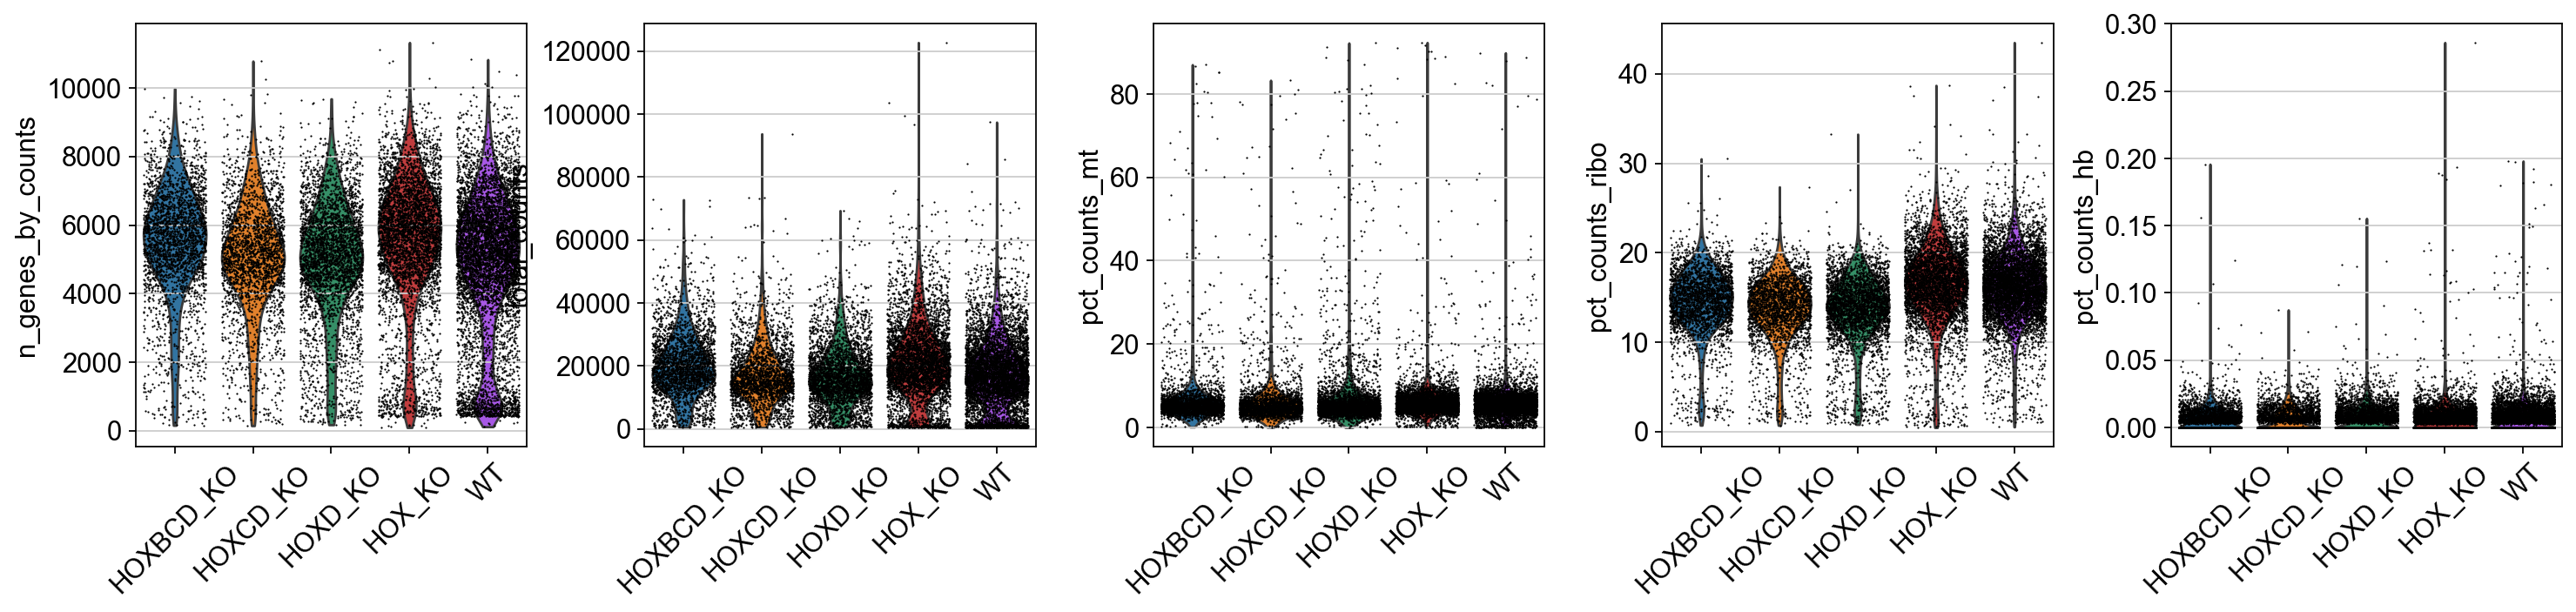

In [18]:
sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt','pct_counts_ribo', 'pct_counts_hb'],
             jitter=0.4, groupby = 'sample', rotation= 45)

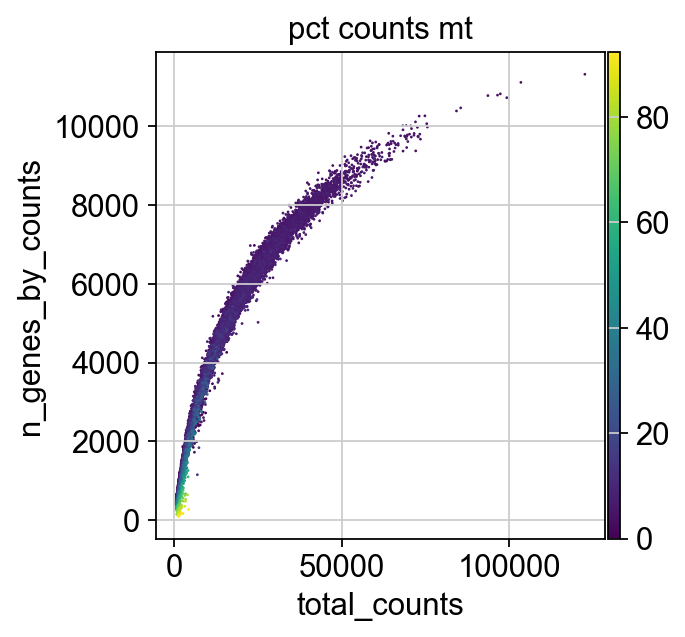

In [19]:
sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

## Filtering

In [20]:
sc.pp.filter_cells(adata, min_genes=1000)  #Normally we do 200, but I increased it as I see an accumulation in the WT sample
sc.pp.filter_genes(adata, min_cells=3)

print(adata.n_obs, adata.n_vars)

filtered out 1088 cells that have less than 1000 genes expressed
filtered out 5967 genes that are detected in less than 3 cells
18476 30634


normalizing counts per cell
    finished (0:00:00)


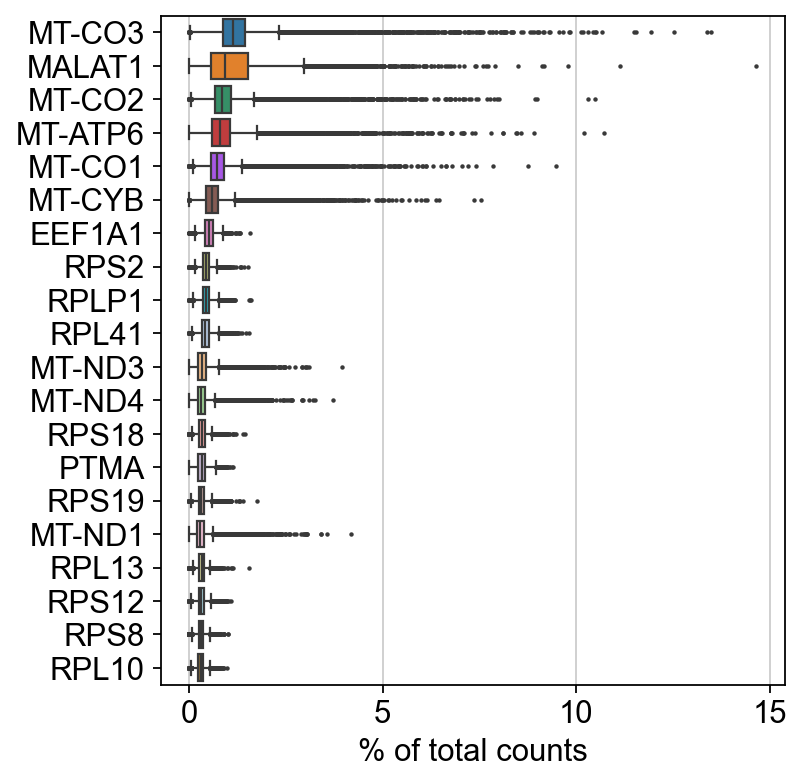

In [21]:
sc.pl.highest_expr_genes(adata, n_top=20)

In [22]:
# filter for percent mito
adata = adata[adata.obs['pct_counts_mt'] < 20, :]
adata = adata[adata.obs['pct_counts_ribo'] > 5, :].copy()

print("Remaining cells %d"%adata.n_obs)

Remaining cells 17951


In [23]:
print(adata.obs['sample'].value_counts())

sample
WT           5714
HOX_KO       4181
HOXD_KO      3179
HOXBCD_KO    2565
HOXCD_KO     2312
Name: count, dtype: int64


In [24]:
malat1 = adata.var_names.str.startswith('MALAT1')
mito_genes = adata.var_names.str.startswith('MT-')
#hb_genes = adata.var_names.str.contains('^HB[^(P)]')
ribo_genes =adata.var_names.str.startswith(("RPS","RPL"))

#remove = np.add(mito_genes, malat1, ribo_genes)
#remove = np.add(remove, hb_genes)
remove = mito_genes | malat1 | ribo_genes
keep = np.invert(remove)

adata = adata[:,keep].copy()

normalizing counts per cell
    finished (0:00:00)


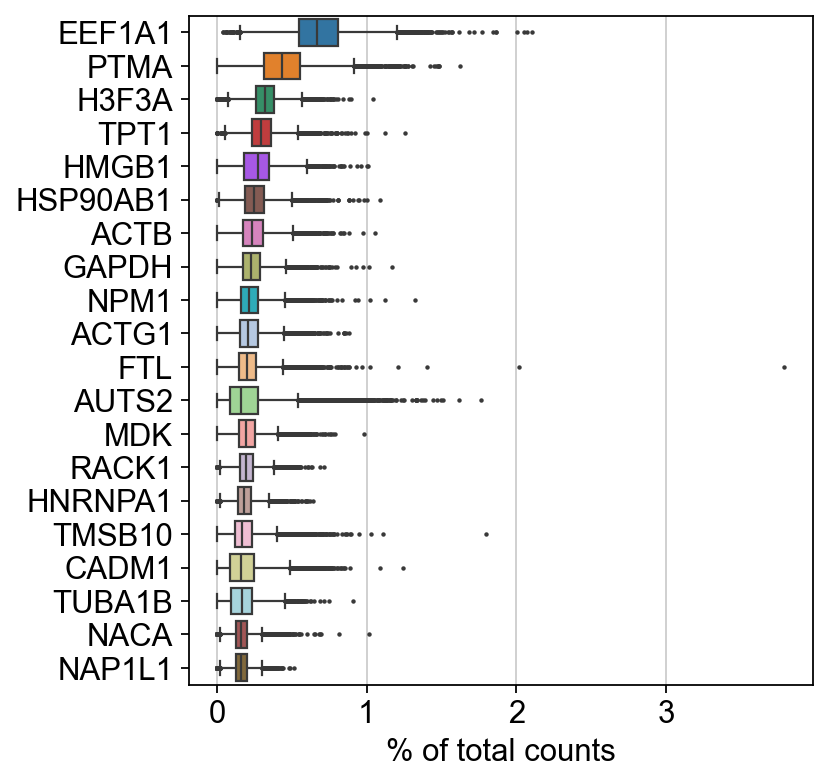

In [25]:
sc.pl.highest_expr_genes(adata, n_top=20)

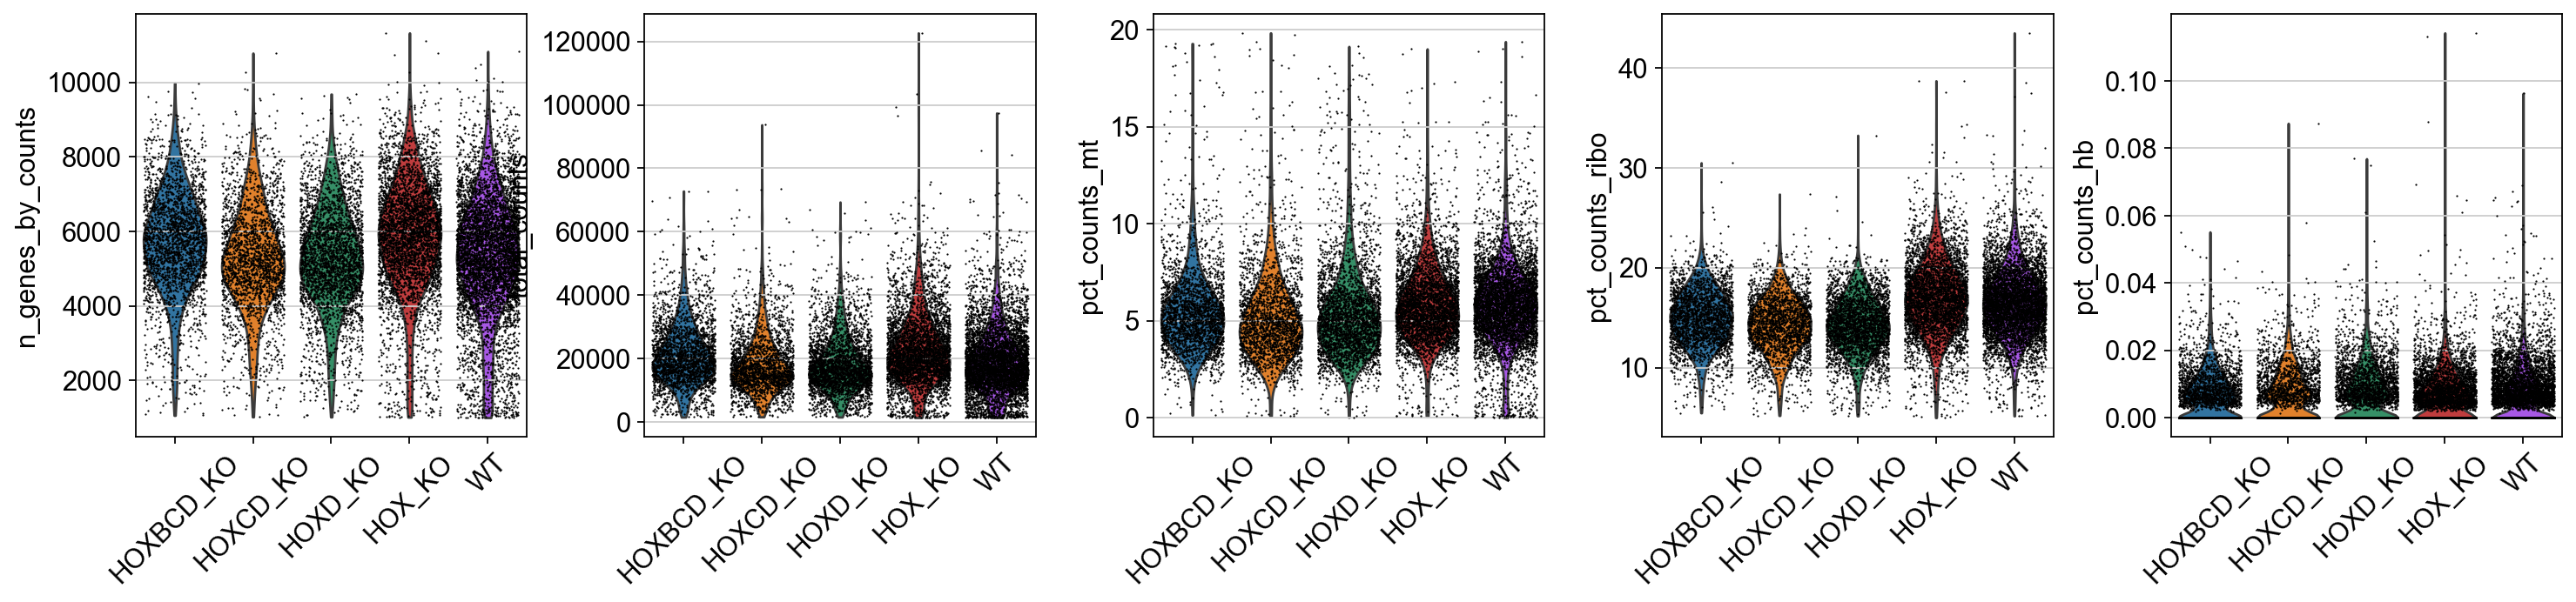

In [26]:
sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt','pct_counts_ribo', 'pct_counts_hb'],
             jitter=0.4, groupby = 'sample', rotation= 45)

## Doublet detection

Doblet prediction should be run on raw counts

In [27]:
sc.pp.scrublet(adata, batch_key="sample",expected_doublet_rate=0.04, threshold=0.20) #threshold visually established

Running Scrublet
filtered out 5096 genes that are detected in less than 3 cells
normalizing counts per cell
    finished (0:00:00)
extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
normalizing counts per cell
    finished (0:00:00)
normalizing counts per cell
    finished (0:00:00)
Embedding transcriptomes using PCA...
    using data matrix X directly
Detected doublet rate = 1.2%
Estimated detectable doublet fraction = 28.8%
Overall doublet rate:
	Expected   = 4.0%
	Estimated  = 4.1%
filtered out 5611 genes that are detected in less than 3 cells
normalizing counts per cell
    finished (0:00:00)
extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
  

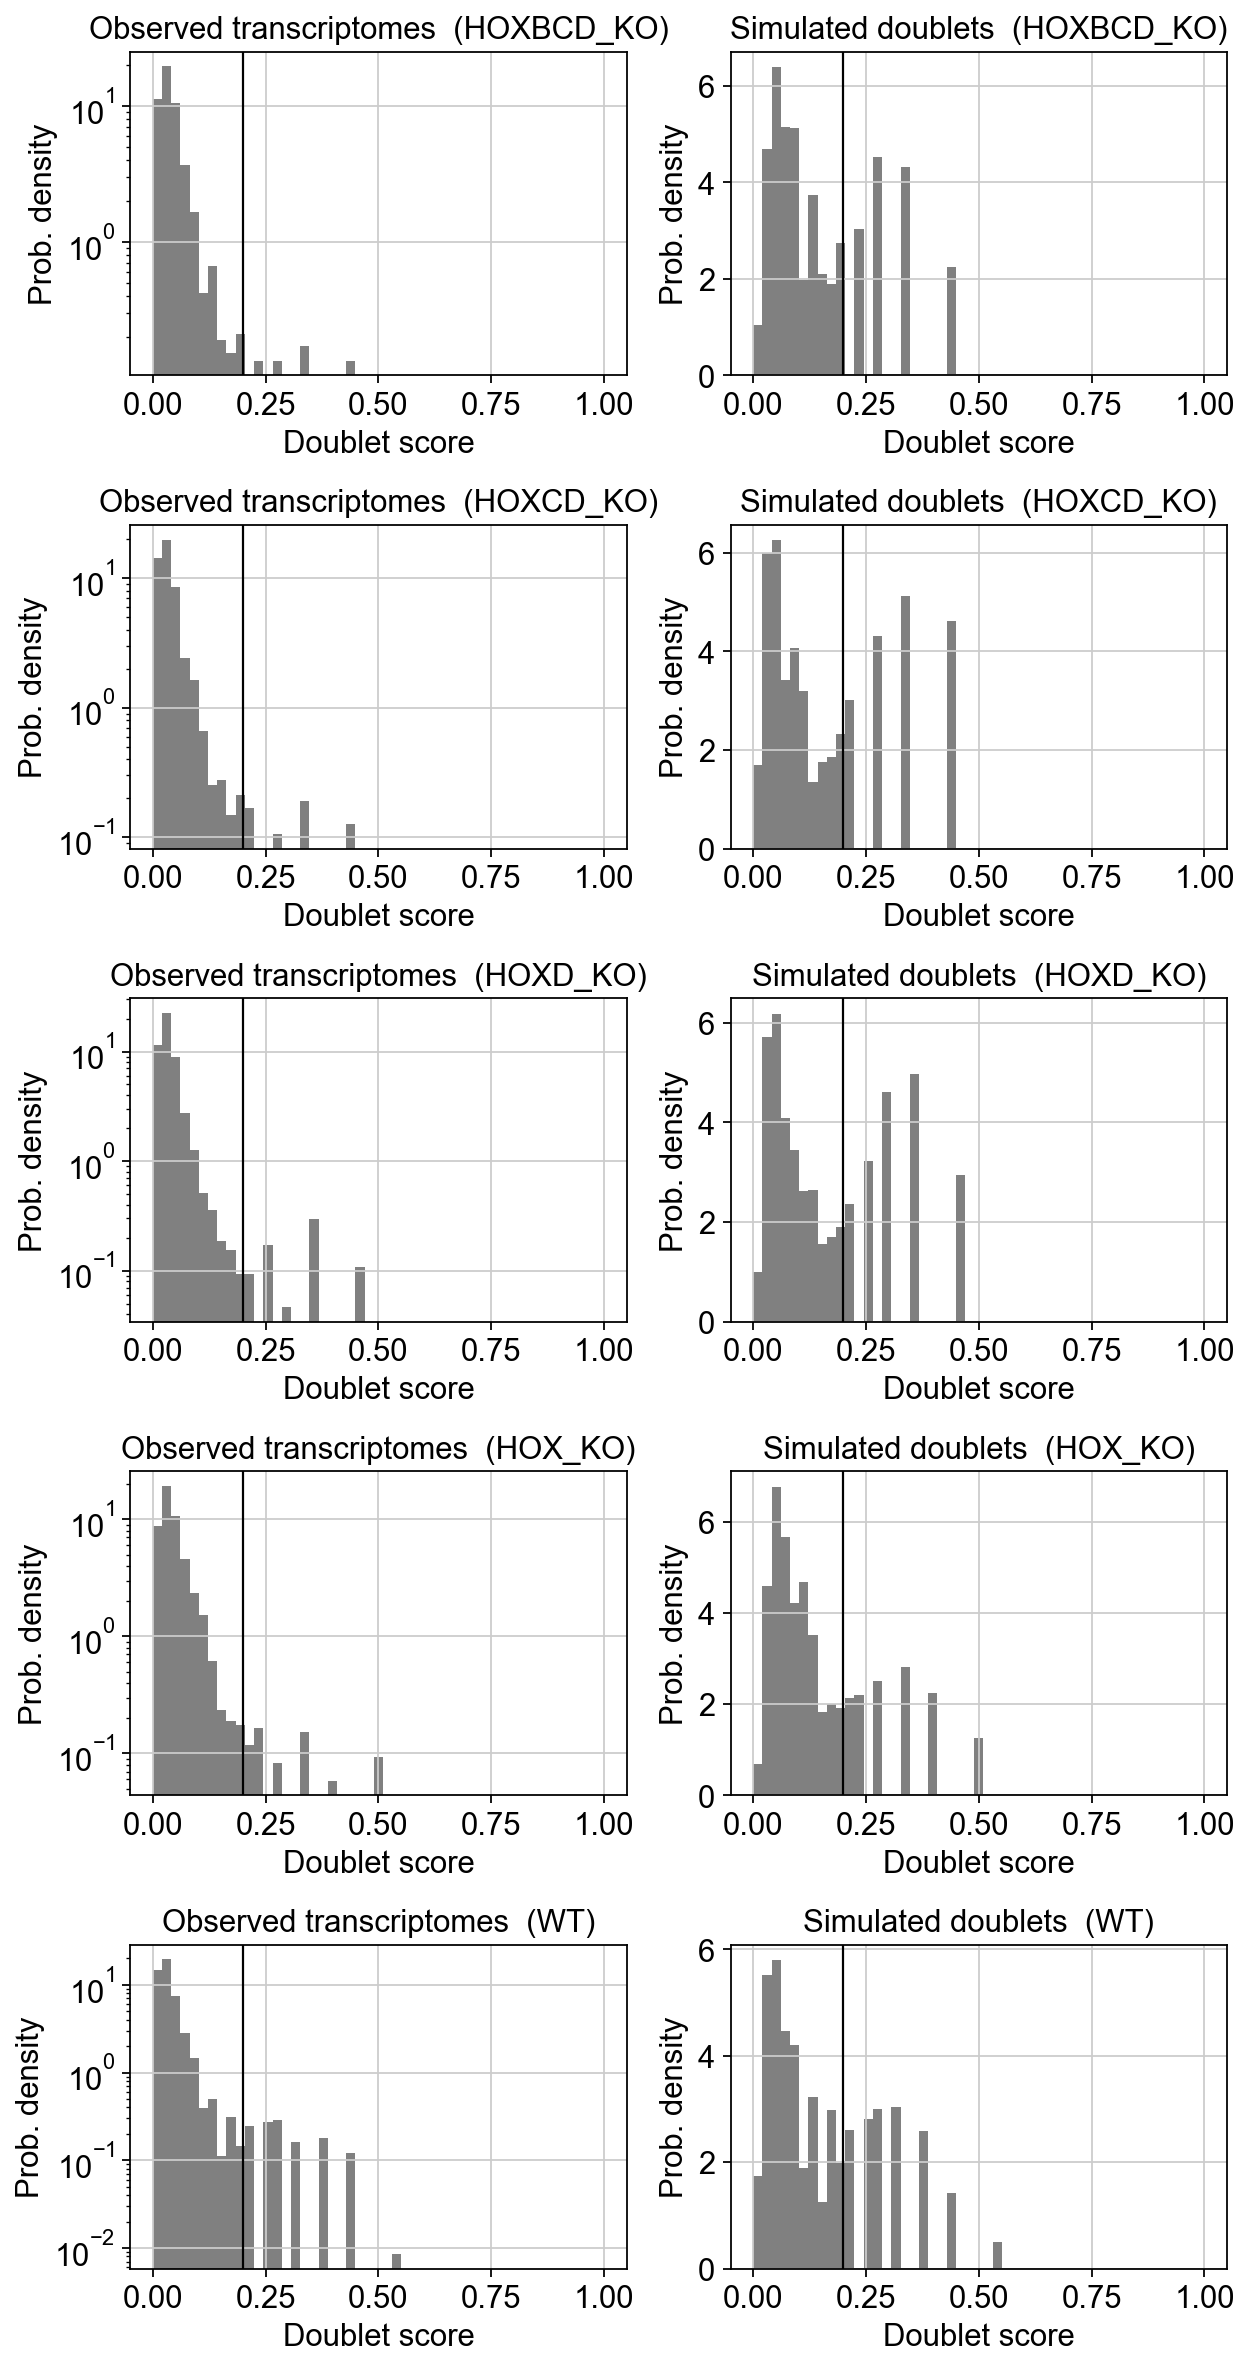

In [28]:
sc.pl.scrublet_score_distribution(adata)

In [29]:
sum(adata.obs['predicted_doublet'])

311

In [30]:
adata= adata[adata.obs['predicted_doublet'] == False,:].copy()
print(adata.shape)

(17640, 30520)


## Calculate cell-cycle scores

In [31]:
cell_cycle_genes = [x.strip() for x in open('./regev_lab_cell_cycle_genes.txt')]
print(len(cell_cycle_genes))

# Split into 2 lists
s_genes = cell_cycle_genes[:43]
g2m_genes = cell_cycle_genes[43:]

cell_cycle_genes = [x for x in cell_cycle_genes if x in adata.var_names]
print(len(cell_cycle_genes))

97
94


In [32]:
#Store raw data 
adata.layers["raw_counts"] = adata.X.copy()

In [33]:
# normalize to depth 10 000
sc.pp.normalize_total(adata, target_sum=1e4)

# logaritmize
sc.pp.log1p(adata)

# save lognorm counts in raw slot.
adata.raw = adata.copy()


normalizing counts per cell
    finished (0:00:00)


In [34]:
print(adata.raw.X[1:10,1:10]) 

  (0, 6)	0.547740638256073
  (3, 4)	0.33367305994033813
  (8, 4)	0.2874073386192322
  (8, 6)	0.510386049747467


In [35]:
sc.tl.score_genes_cell_cycle(adata, s_genes=s_genes, g2m_genes=g2m_genes)

calculating cell cycle phase
computing score 'S_score'
    finished: added
    'S_score', score of gene set (adata.obs).
    300 total control genes are used. (0:00:01)
computing score 'G2M_score'
    finished: added
    'G2M_score', score of gene set (adata.obs).
    300 total control genes are used. (0:00:01)
-->     'phase', cell cycle phase (adata.obs)


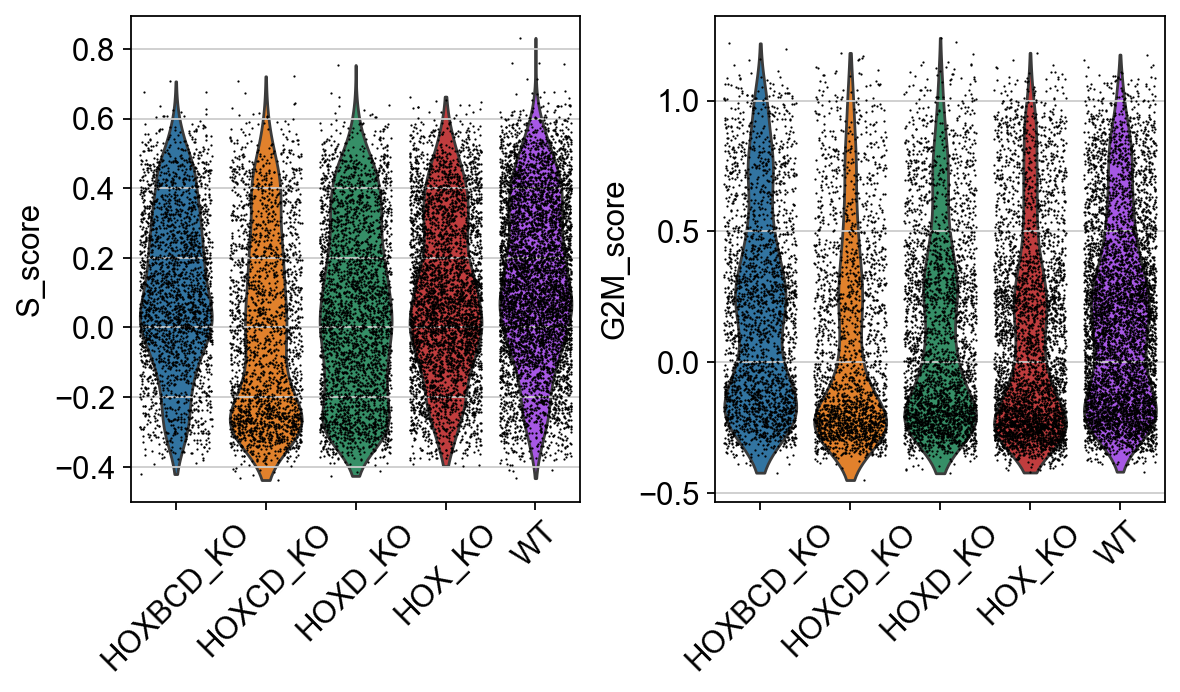

In [36]:
sc.pl.violin(adata, ['S_score', 'G2M_score'],
             jitter=0.4, groupby = 'sample', rotation=45)

In [37]:
save_file = 'H5AD/20241113_HOXsamples_all_qc_filtered.h5ad'
adata.write_h5ad(save_file)

## DIMENSION REDUCTION

In [38]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt

sc.settings.verbosity = 3             # verbosity: errors (0), warnings (1), info (2), hints (3)
#sc.logging.print_versions()

In [39]:
sc.settings.set_figure_params(dpi=80)

In [40]:
adata = sc.read_h5ad('H5AD/20241113_HOXsamples_all_qc_filtered.h5ad')

The data has been already normalized and log.

extracting highly variable genes
    finished (0:00:02)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
Highly variable genes: 3528


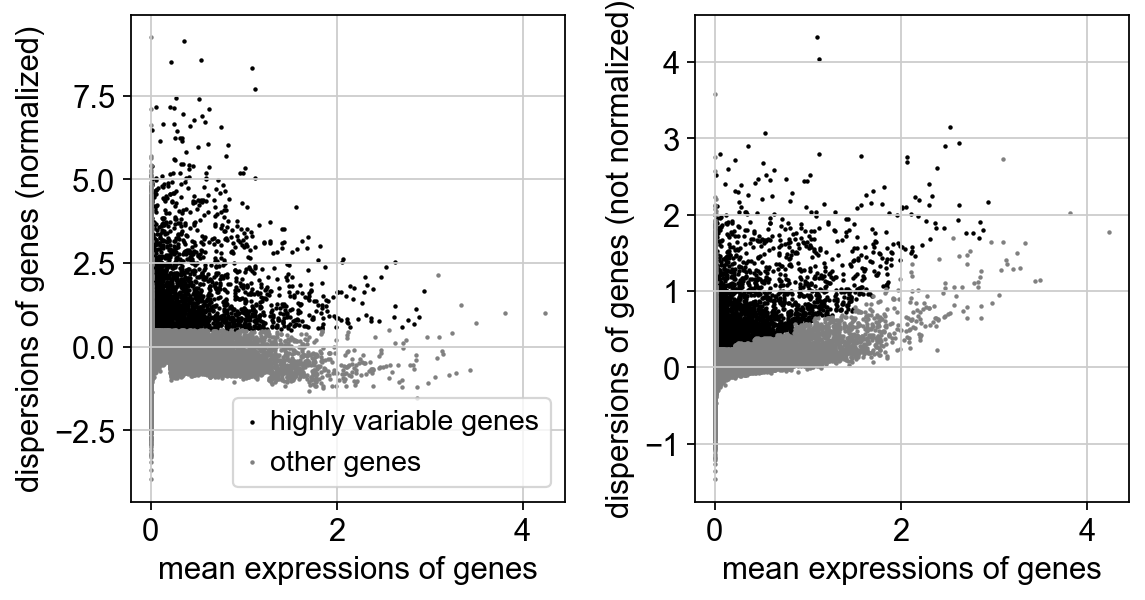

In [41]:
# compute variable genes
sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)
print("Highly variable genes: %d"%sum(adata.var.highly_variable))

#plot variable genes
sc.pl.highly_variable_genes(adata)
#
adata = adata[:, adata.var['highly_variable']].copy()

### PCA

In [42]:
# regress out unwanted variables
sc.pp.regress_out(adata, ['total_counts', 'pct_counts_mt','S_score', 'G2M_score'])
# scale data, clip values exceeding standard deviation 10.
sc.pp.scale(adata, max_value=10)

regressing out ['total_counts', 'pct_counts_mt', 'S_score', 'G2M_score']
    sparse input is densified and may lead to high memory use
    finished (0:01:06)


In [43]:
print(adata.raw.X[1:10,1:10]) 

  (0, 6)	0.547740638256073
  (3, 4)	0.33367305994033813
  (8, 4)	0.2874073386192322
  (8, 6)	0.510386049747467


In [44]:
sc.tl.pca(adata, svd_solver='arpack')

computing PCA
    with n_comps=50
    finished (0:00:09)


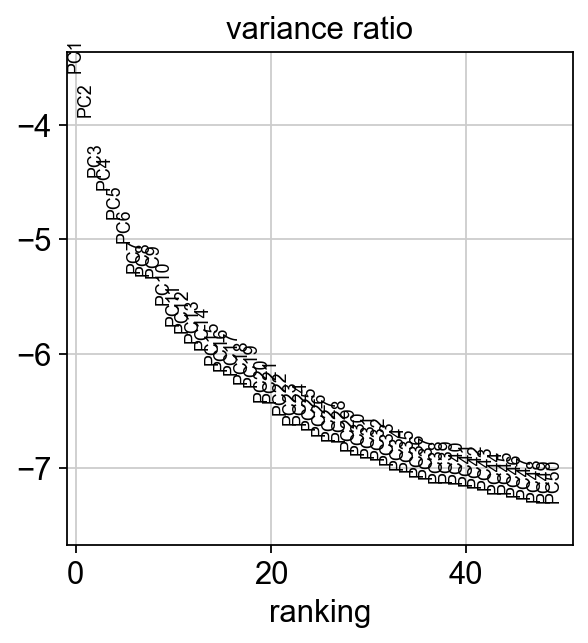

In [45]:
sc.pl.pca_variance_ratio(adata, log=True, n_pcs = 50)

### Running UMAP with regression and scalling

In [46]:
sc.tl.tsne(adata, n_pcs = 50)

computing tSNE
    using 'X_pca' with n_pcs = 50
    using sklearn.manifold.TSNE
    finished: added
    'X_tsne', tSNE coordinates (adata.obsm) (0:01:39)


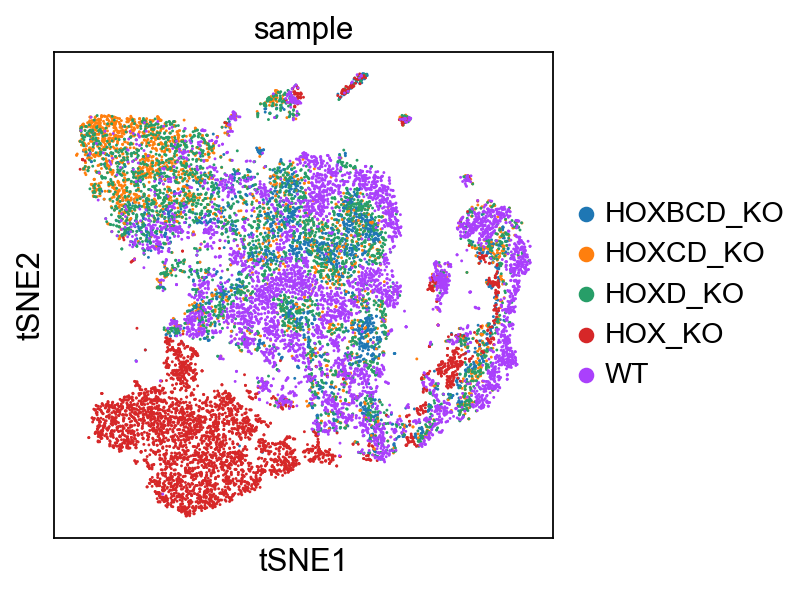

In [47]:
sc.pl.tsne(adata, color='sample')

In [48]:
sc.pp.neighbors(adata, n_pcs = 50, n_neighbors = 5)  #later on we will process this with Harmony PCA

computing neighbors
    using 'X_pca' with n_pcs = 50
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:07)


In [49]:
sc.tl.umap(adata)

computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm) (0:00:07)


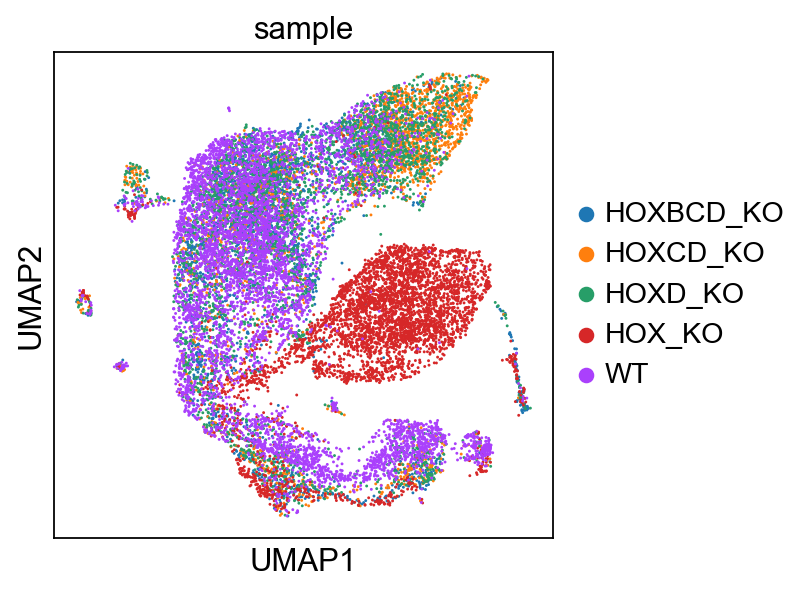

In [50]:
sc.pl.umap(adata, color='sample', save="20241113_HOXsamples_all_UMAP_regrscalling.pdf")

In [51]:
adata.write_h5ad('H5AD/20241113_HOXsamples_all_qc_filtered_dr.h5ad')

In [52]:
print(adata.X.shape)  # contains the variable genes, scaled and corrected
print(adata.raw.X.shape)  #contains all genes, normalized and log 

(17640, 3528)
(17640, 30520)


# INTEGRATION

In [53]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt

sc.settings.verbosity = 3             # verbosity: errors (0), warnings (1), info (2), hints (3)
#sc.logging.print_versions()

sc.settings.set_figure_params(dpi=80)
%matplotlib inline

In [54]:
save_file = 'H5AD/20241113_HOXsamples_all_qc_filtered_dr.h5ad'
adata = sc.read_h5ad(save_file)

In [55]:
print(adata.X.shape)  # contains the variable genes, scaled and corrected
print(adata.raw.X.shape)  #contains all genes, normalized and log 
adata.layers['raw_counts']  #contains our raw counts!

(17640, 3528)
(17640, 30520)


<17640x3528 sparse matrix of type '<class 'numpy.float32'>'
	with 14664876 stored elements in Compressed Sparse Row format>

*Optional*: you can proceed without getting back to normalized counts in adata, but remember to set Use_raw=True for downstream analysis

In [56]:
# We need to make a new object with the logtransformed normalized counts
adata = adata.raw.to_adata() 
#we lost some variables

# check that the matrix looks like normalized counts
print(adata.X[1:10,1:10])

  (0, 6)	0.547740638256073
  (3, 4)	0.33367305994033813
  (8, 4)	0.2874073386192322
  (8, 6)	0.510386049747467


In [57]:
sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5, batch_key = 'sample')

extracting highly variable genes
    finished (0:00:03)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)


## Integrate with Harmony 

In [58]:
sc.external.pp.harmony_integrate(adata, key="sample")


2024-11-13 10:22:38,151 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2024-11-13 10:22:40,119 - harmonypy - INFO - sklearn.KMeans initialization complete.
2024-11-13 10:22:40,247 - harmonypy - INFO - Iteration 1 of 10
2024-11-13 10:22:44,776 - harmonypy - INFO - Iteration 2 of 10
2024-11-13 10:22:49,190 - harmonypy - INFO - Iteration 3 of 10
2024-11-13 10:22:53,609 - harmonypy - INFO - Iteration 4 of 10
2024-11-13 10:22:58,022 - harmonypy - INFO - Iteration 5 of 10
2024-11-13 10:23:02,560 - harmonypy - INFO - Converged after 5 iterations


In [59]:
adata.obsm['X_pca'] = adata.obsm['X_pca_harmony'].copy()
sc.pp.neighbors(adata, n_neighbors=5, n_pcs=50)
sc.tl.umap(adata)

computing neighbors
    using 'X_pca' with n_pcs = 50
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:02)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm) (0:00:07)


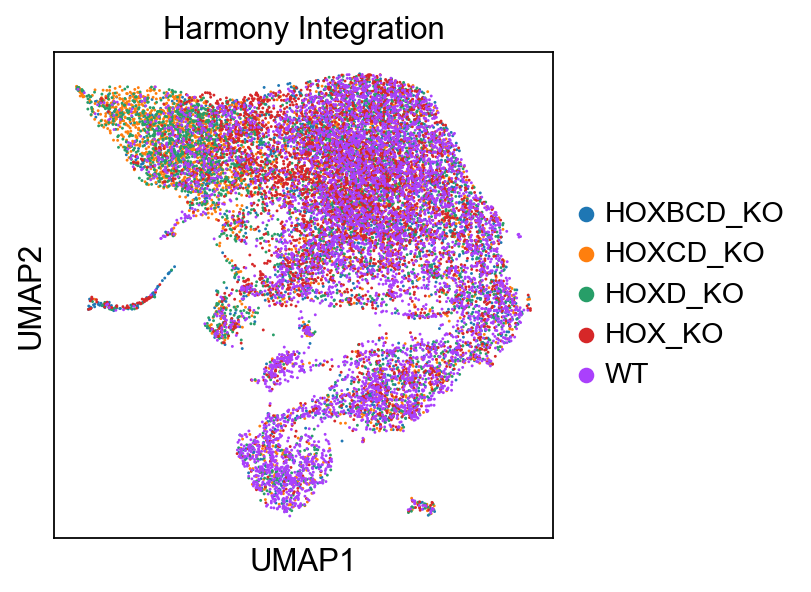

In [60]:
sc.pl.umap(adata, color="sample", title="Harmony Integration", save="20241113_HOXsamples_all_UMAP_Harmony_persample.pdf")

In [61]:
save_file = 'H5AD/20241113_HOXsamples_all_qc_filtered_dr_Harmony.h5ad'
adata.write_h5ad(save_file)

In [62]:
all_hox_genes= [ "HOXA1","HOXA2", "HOXA3", "HOXA4", "HOXA5","HOXA6","HOXA7","HOXA8","HOXA9","HOXA10","HOXA11", "HOXA12","HOXA13",
                 "HOXB1","HOXB2", "HOXB3", "HOXB4", "HOXB5","HOXB6","HOXB7","HOXB8","HOXB9","HOXB10","HOXB11", "HOXB12","HOXB13",
                 "HOXC1","HOXC2", "HOXC3", "HOXC4", "HOXC5","HOXC6","HOXC7","HOXC8","HOXC9","HOXC10","HOXC11","HOXC12","HOXC13",
                 "HOXD1","HOXD2", "HOXD3", "HOXD4", "HOXD5","HOXD6","HOXD7","HOXD8","HOXD9","HOXD10","HOXD11","HOXD12", "HOXD13"]

In [63]:
# Let's check which HOX genes are not expressed
gene_of_interest = all_hox_genes

for gene in gene_of_interest:
    if gene not in adata.var_names:
        print(f"Gene {gene} not found in the dataset.")
        continue

Gene HOXA8 not found in the dataset.
Gene HOXA11 not found in the dataset.
Gene HOXA12 not found in the dataset.
Gene HOXB10 not found in the dataset.
Gene HOXB11 not found in the dataset.
Gene HOXB12 not found in the dataset.
Gene HOXC1 not found in the dataset.
Gene HOXC2 not found in the dataset.
Gene HOXC3 not found in the dataset.
Gene HOXC7 not found in the dataset.
Gene HOXC11 not found in the dataset.
Gene HOXC12 not found in the dataset.
Gene HOXD2 not found in the dataset.
Gene HOXD5 not found in the dataset.
Gene HOXD6 not found in the dataset.
Gene HOXD7 not found in the dataset.
Gene HOXD10 not found in the dataset.
Gene HOXD11 not found in the dataset.
Gene HOXD12 not found in the dataset.


In [64]:
hox_genes= ["HOXA1","HOXA2", "HOXA3", "HOXA4", "HOXA5","HOXA6","HOXA7","HOXA9","HOXA10","HOXA13", #'HOXA8', "HOXA11","HOXA12" not expressed
            "HOXB1","HOXB2", "HOXB3", "HOXB4", "HOXB5","HOXB6","HOXB7","HOXB8","HOXB9","HOXB13",  # "HOXB10","HOXB11","HOXB12" not expressed
            "HOXC4","HOXC5","HOXC6","HOXC8","HOXC9","HOXC10",'HOXC13', # 'HOXC1','HOXC2', 'HOXC3',  'HOXC7', 'HOXC11', 'HOXC12' not expressed
            "HOXD1","HOXD3", "HOXD4","HOXD8", "HOXD9","HOXD13" # 'HOXD2', 'HOXD5', 'HOXD6', 'HOXD7', 'HOXD10', 'HOXD11', 'HOXD12', not expressed
           ]

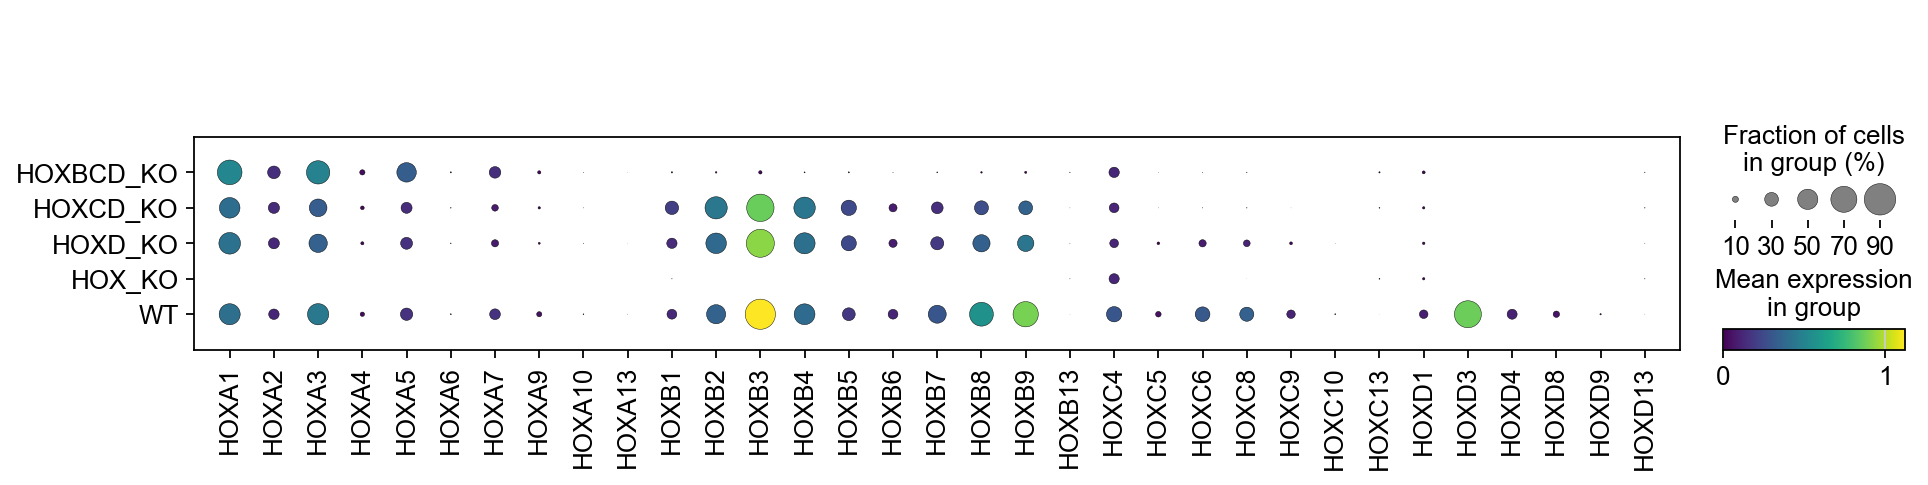

In [65]:
sc.pl.dotplot(adata,hox_genes, groupby='sample',color_map="viridis", save="20241113_Dotplot_HOXgenes_allsamples.pdf")

Scaled version:

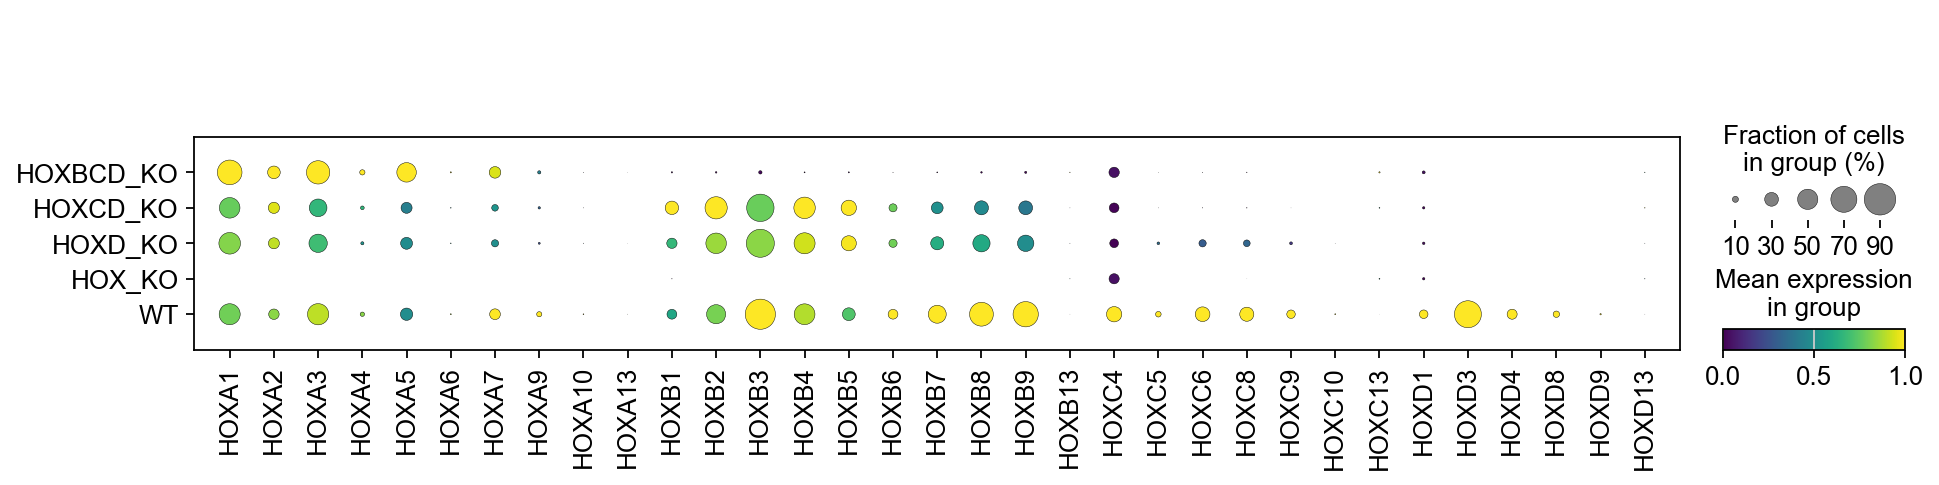

In [66]:
sc.pl.dotplot(adata,hox_genes, groupby='sample',color_map="viridis", standard_scale="var", save="20241113_Dotplot_HOXgenes_allsamples_std.pdf")

## Clustering

In [67]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt

sc.settings.verbosity = 3             # verbosity: errors (0), warnings (1), info (2), hints (3)
#sc.logging.print_versions()

In [68]:
sc.settings.set_figure_params(dpi=80)

In [69]:
# select the harmony integration data.

save_file = 'H5AD/20241113_HOXsamples_all_qc_filtered_dr_Harmony.h5ad'
adata = sc.read_h5ad(save_file)

In [70]:
adata #contains all genes log norm

AnnData object with n_obs × n_vars = 17640 × 30520
    obs: 'sample', 'batch', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'pct_counts_hb', 'n_genes', 'doublet_score', 'predicted_doublet', 'S_score', 'G2M_score', 'phase'
    var: 'gene_ids', 'feature_types', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'hvg', 'log1p', 'neighbors', 'pca', 'sample_colors', 'scrublet', 'tsne', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_tsne', 'X_umap'
    obsp: 'connectivities', 'distances'

In [71]:
adata.raw = adata.copy() 

## Leiden clustering

In [72]:
sc.tl.leiden(adata, resolution = 0.1, key_added = "leiden_0.1")
sc.tl.leiden(adata, resolution = 0.2, key_added = "leiden_0.2")
sc.tl.leiden(adata, resolution = 0.25, key_added = "leiden_0.25")

running Leiden clustering


C:\Users\aleja\AppData\Local\Temp\ipykernel_9612\1994173383.py:1: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution = 0.1, key_added = "leiden_0.1")


    finished: found 7 clusters and added
    'leiden_0.1', the cluster labels (adata.obs, categorical) (0:00:00)
running Leiden clustering
    finished: found 12 clusters and added
    'leiden_0.2', the cluster labels (adata.obs, categorical) (0:00:00)
running Leiden clustering
    finished: found 13 clusters and added
    'leiden_0.25', the cluster labels (adata.obs, categorical) (0:00:00)


In [73]:
sc.tl.leiden(adata, resolution = 0.3, key_added = "leiden_0.3")

running Leiden clustering
    finished: found 14 clusters and added
    'leiden_0.3', the cluster labels (adata.obs, categorical) (0:00:00)


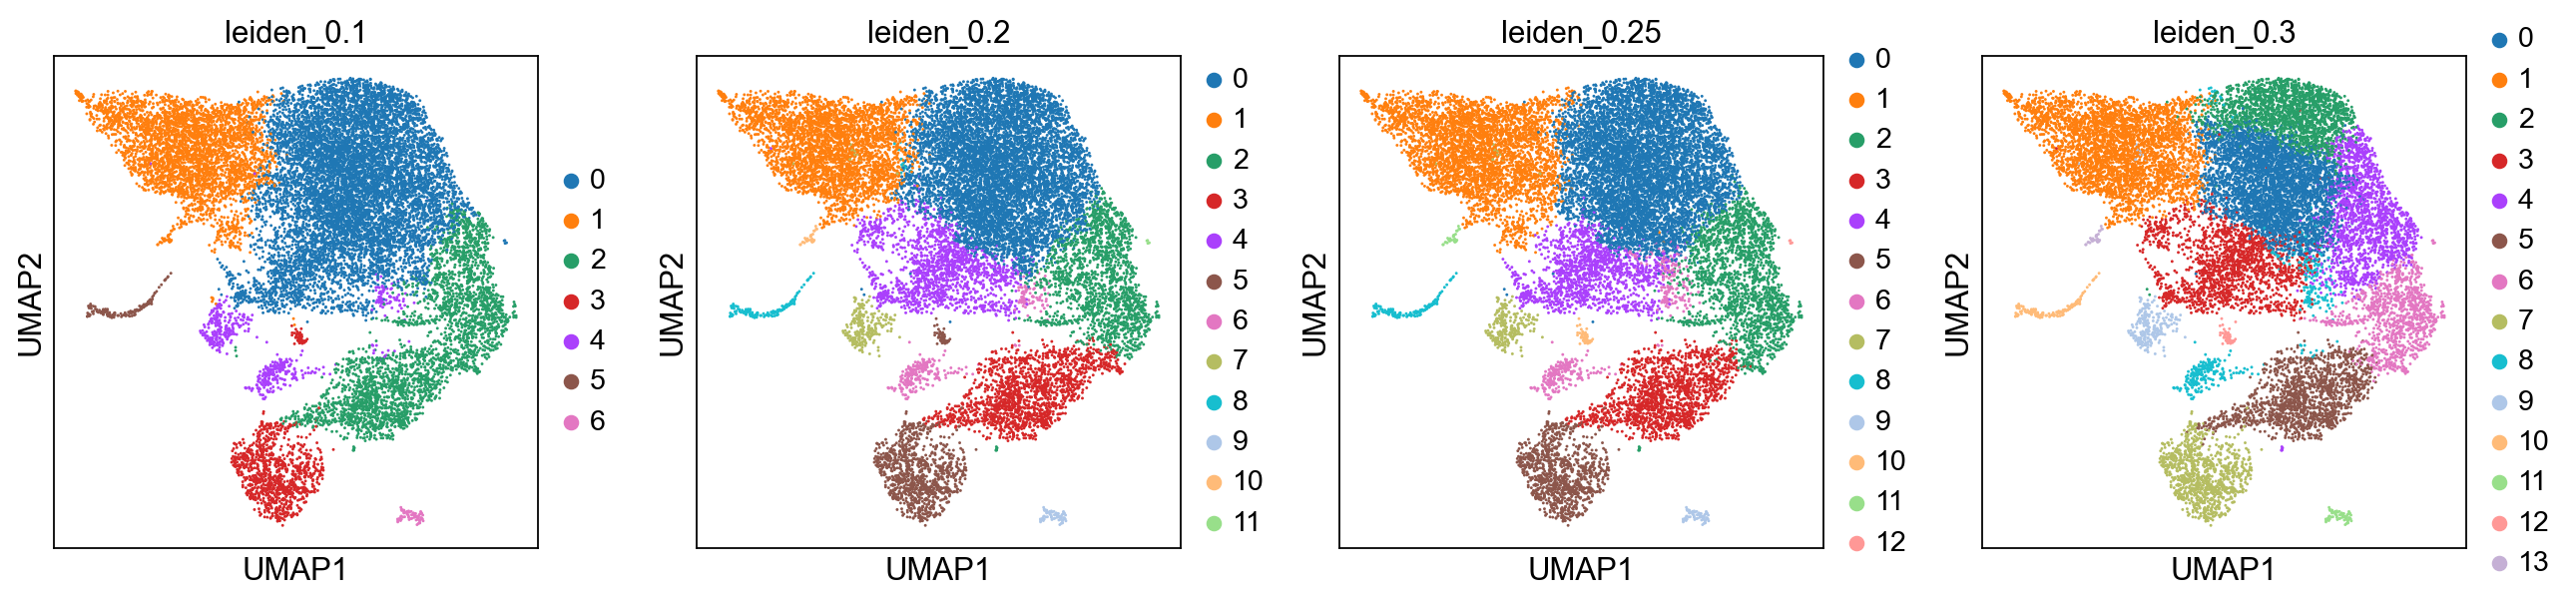

In [74]:
sc.pl.umap(adata, color=['leiden_0.1','leiden_0.2','leiden_0.25','leiden_0.3'])

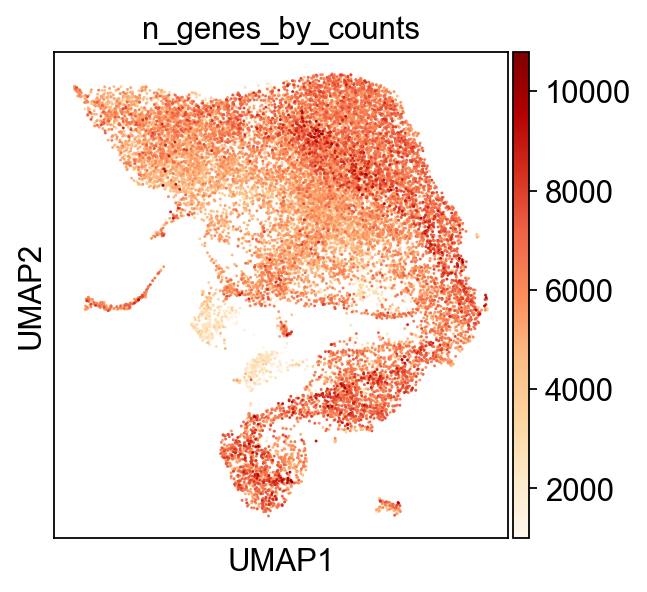

In [75]:
sc.pl.umap(adata, color="n_genes_by_counts", color_map="OrRd")  # some clusters (6,7 r =0.25) show clear decrease in number of genes

In [76]:
print(adata.obs['leiden_0.25'].value_counts())   #cluster 12 is really small  


leiden_0.25
0     6987
1     3872
2     1937
3     1514
4     1356
5     1004
6      412
7      261
8      143
9       68
10      52
11      30
12       4
Name: count, dtype: int64


    using 'X_pca' with n_pcs = 50
Storing dendrogram info using `.uns['dendrogram_leiden_0.25']`


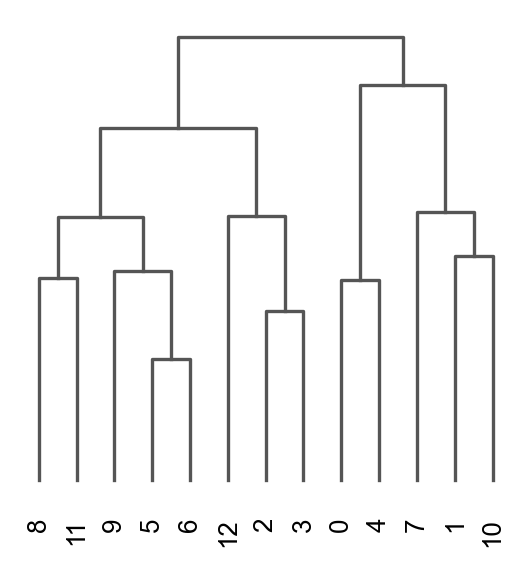

<Axes: >

In [77]:
sc.tl.dendrogram(adata, groupby = "leiden_0.25")
sc.pl.dendrogram(adata, groupby = "leiden_0.25")

In [78]:
genes  = ["NKX1-2","SOX2","CDX2","CDX4", "TBXT",  # NMP
          "TBX6","MSGN1","HES7","MESP1","MESP2","MEOX1","RIPPLY1","FOXC2","MEOX2","ALDH1A2", 'PAX3','TCF15',"SIX1","EYA1","EYA2",  #Mesoderm
          "FOXA2", "NOTO","SHH",  #notochord
          "PAX6","MAP2", #dorsal neural
          "JAG1","PAX8","PAX2",  "GDNF", #nephric
          "TBX1","TWIST1","TCF21", # anteriorParaxialMesoderm
          "KDR","SOX17", "CD34"  # endothelial
         ]

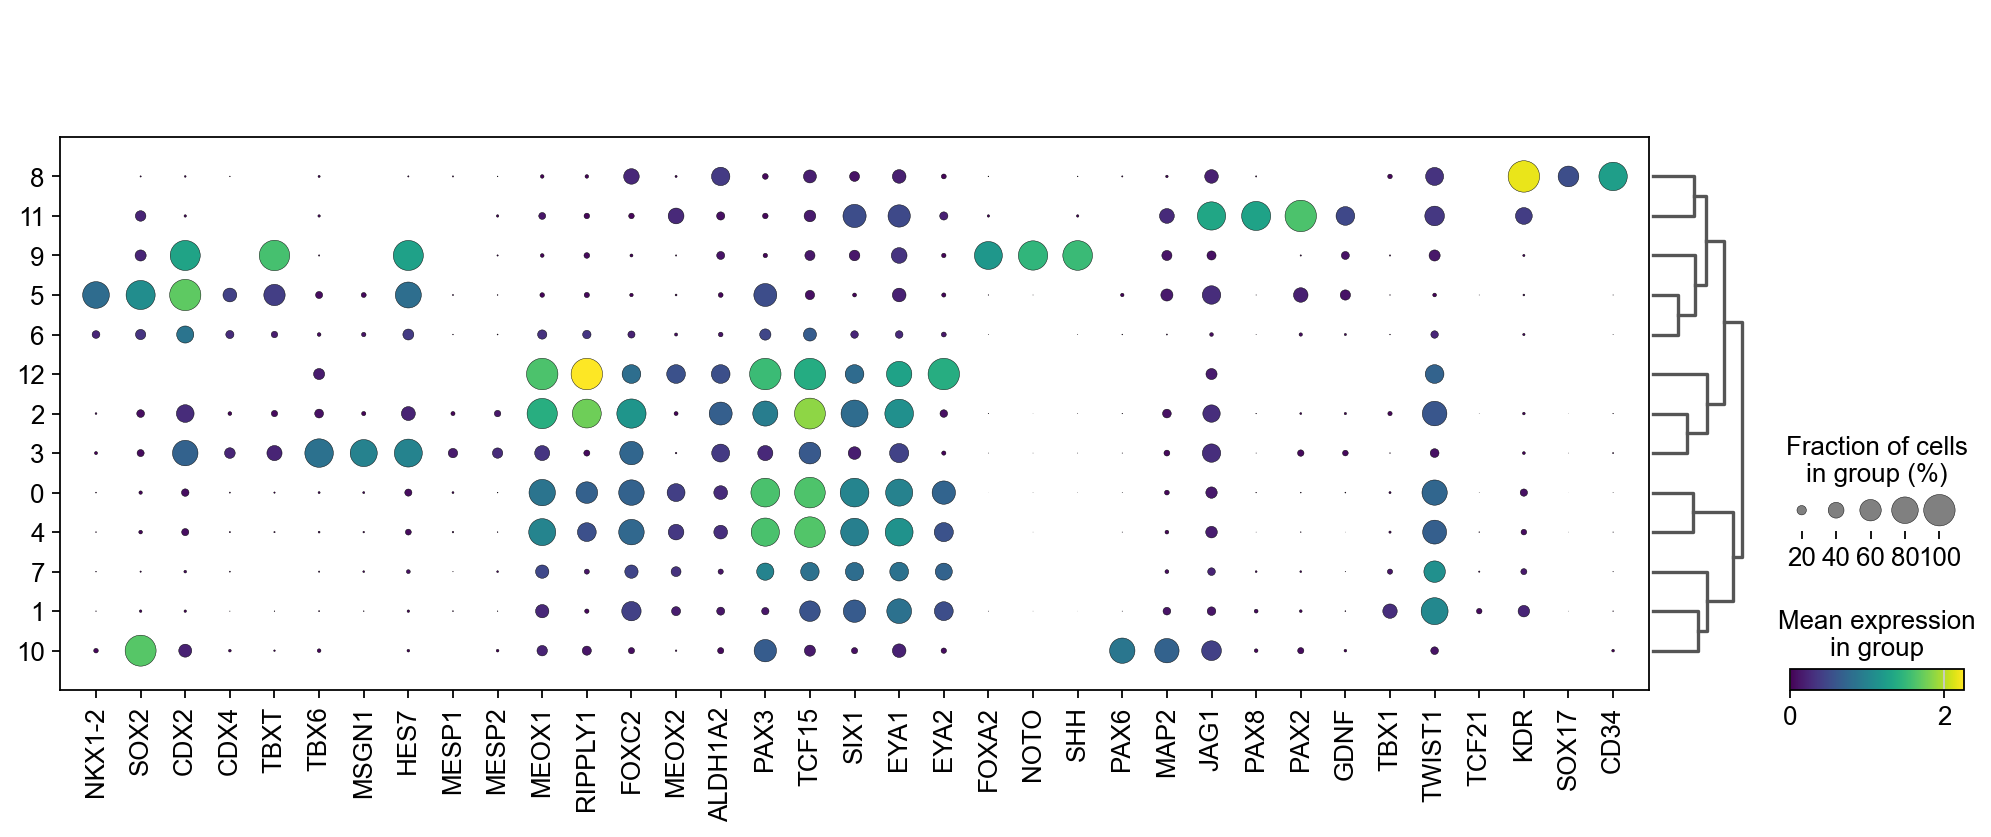

In [79]:
sc.pl.dotplot(adata, genes, groupby='leiden_0.25', color_map="viridis", dendrogram=True)

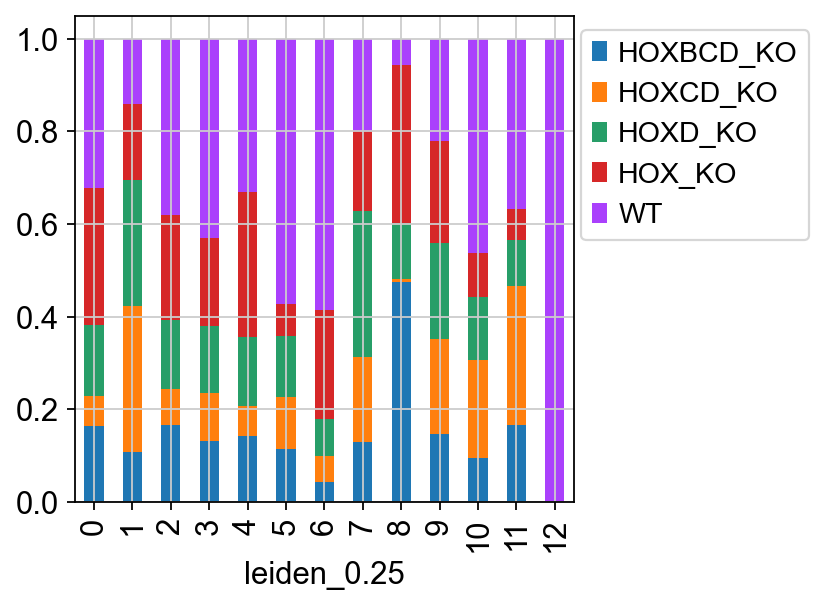

In [80]:
tmp = pd.crosstab(adata.obs['leiden_0.25'],adata.obs['sample'], normalize='index')
tmp.plot.bar(stacked=True).legend(loc='upper right',bbox_to_anchor=(1.5,1))

In [81]:
adata.write_h5ad('H5AD/20241113_HOXsamples_all_qc_filtered_dr_Harmony_clustered.h5ad')

## Differential gene expression

In [82]:
import numpy as np
import pandas as pd
import scanpy as sc
import gseapy
import matplotlib.pyplot as plt

sc.settings.verbosity = 2             # verbosity: errors (0), warnings (1), info (2), hints (3)
#sc.logging.print_versions()


In [83]:
adata = sc.read_h5ad('H5AD/20241113_HOXsamples_all_qc_filtered_dr_Harmony_clustered.h5ad')

In [84]:
print(adata.X.shape) #log norm counts 
print(adata.raw.X.shape)  #log norm counts
print(adata.raw.X[:10,:10])

(17640, 30520)
(17640, 30520)
  (1, 7)	0.547740638256073
  (4, 5)	0.33367305994033813
  (9, 5)	0.2874073386192322
  (9, 7)	0.510386049747467


In [85]:
print(adata.X[:10,:10])

  (1, 7)	0.547740638256073
  (4, 5)	0.33367305994033813
  (9, 5)	0.2874073386192322
  (9, 7)	0.510386049747467


## Wilcoxon rank-sum

ranking genes
    finished (0:01:09)


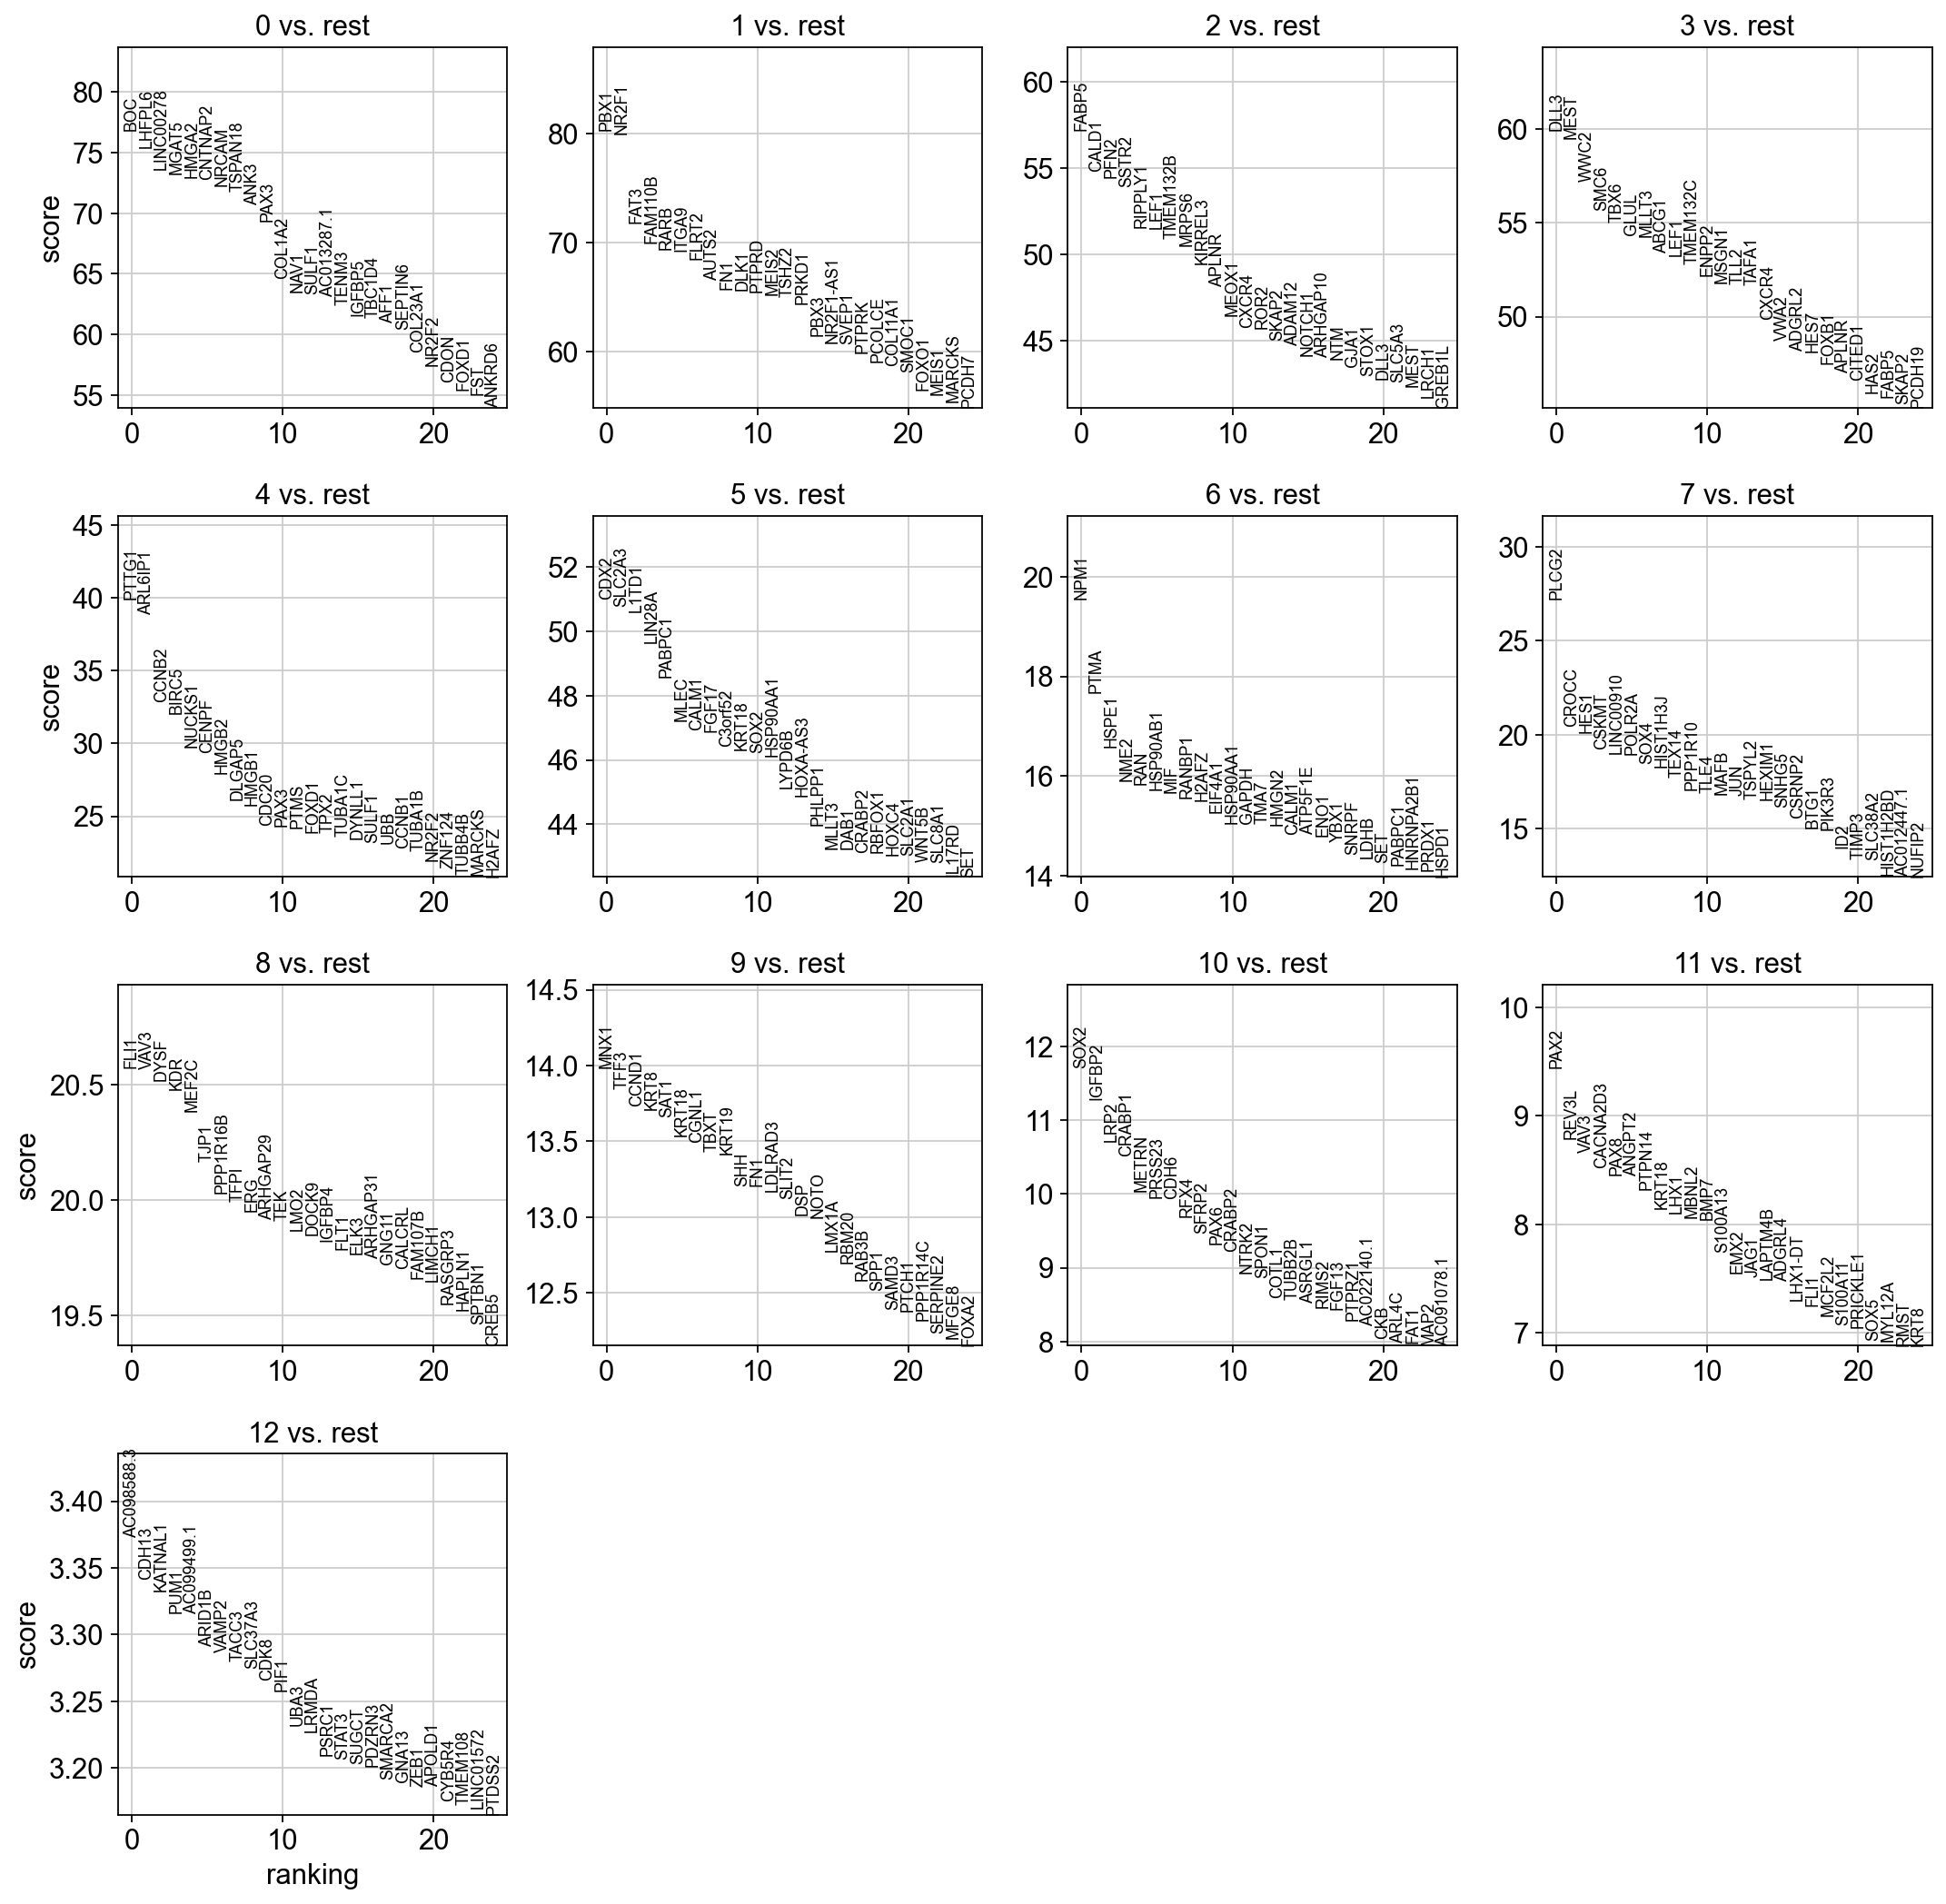

In [86]:
sc.tl.rank_genes_groups(adata, 'leiden_0.25', method='wilcoxon', key_added = "wilcoxon")
sc.pl.rank_genes_groups(adata, n_genes=25, sharey=False, key="wilcoxon")

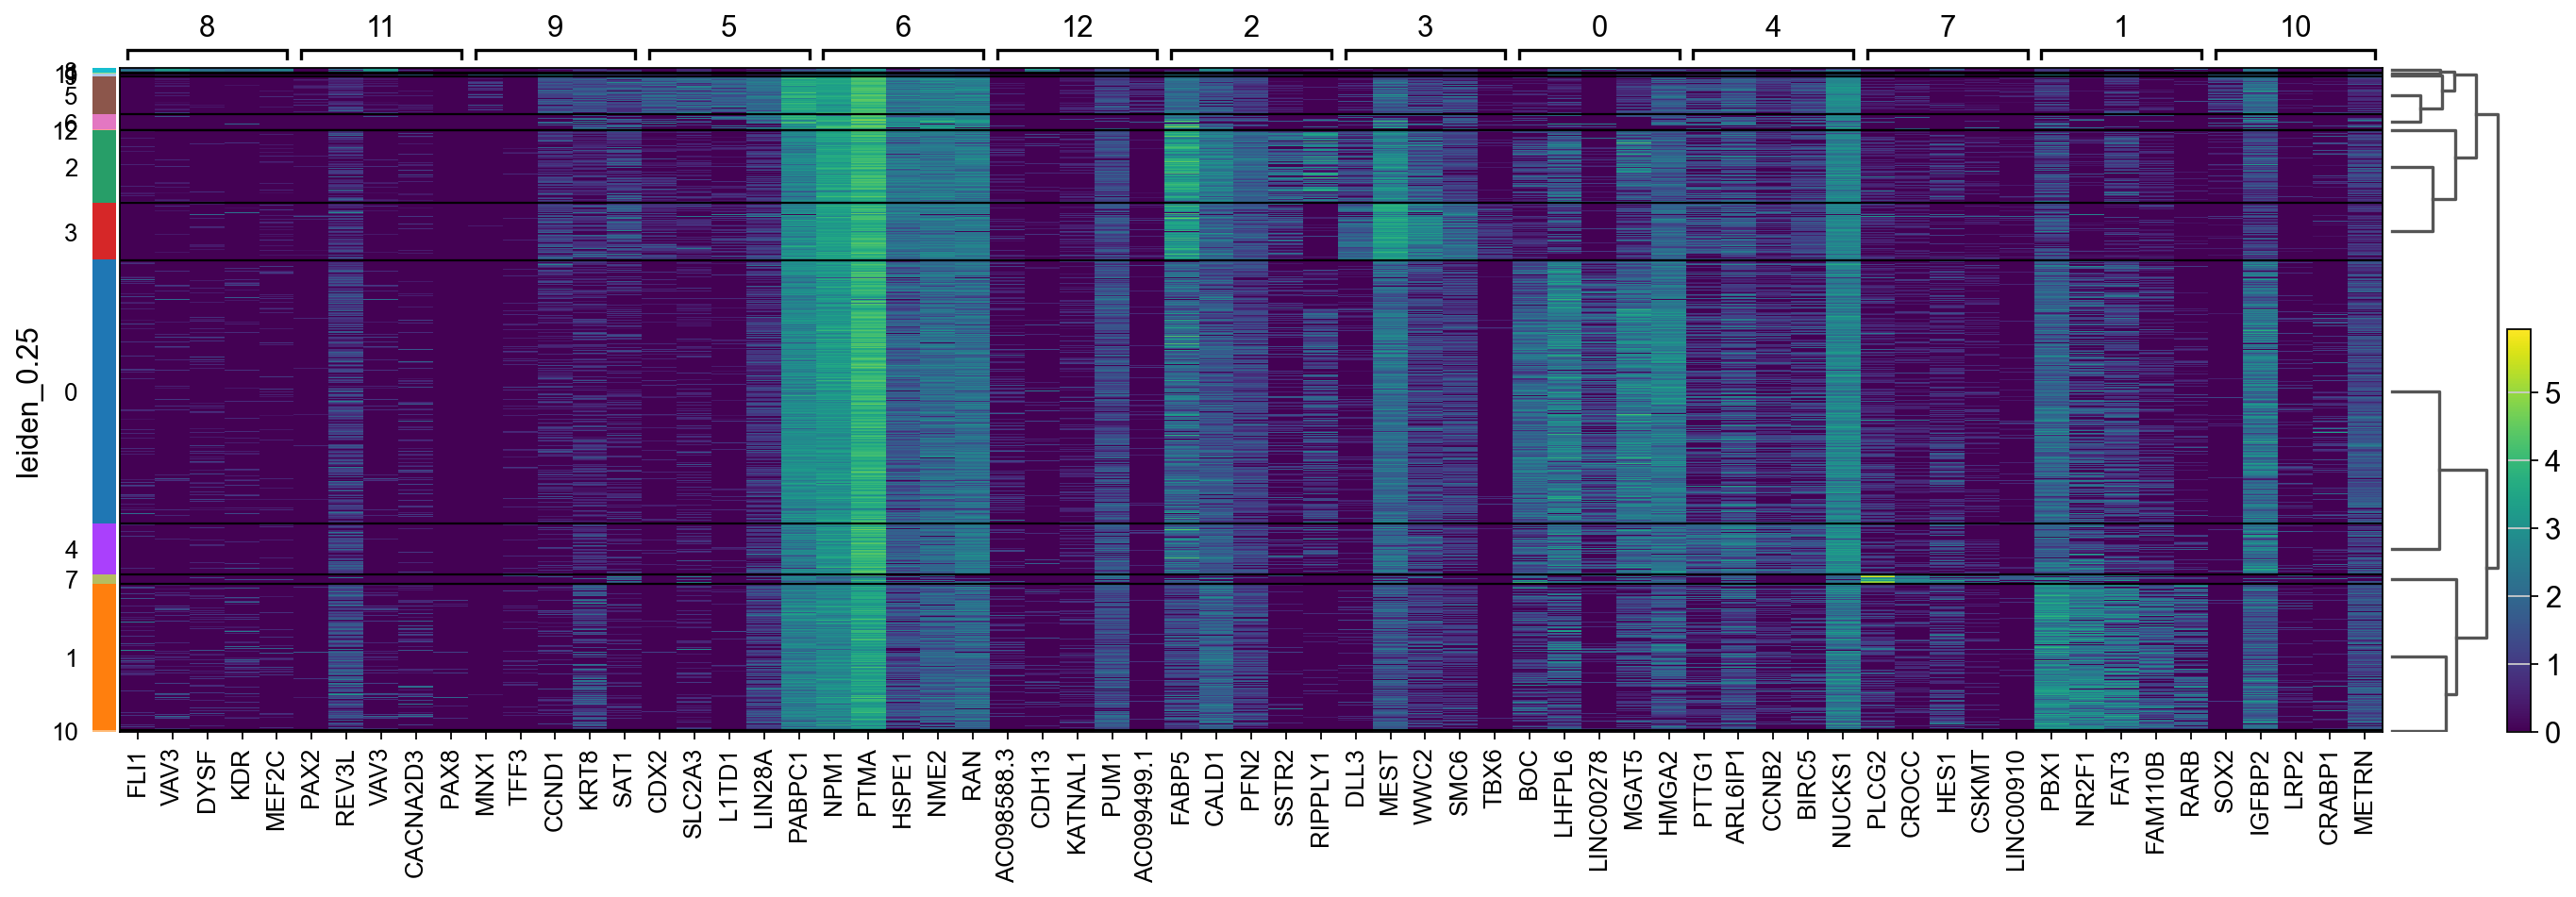

In [87]:
sc.pl.rank_genes_groups_heatmap(adata, n_genes=5, key="wilcoxon", groupby="leiden_0.25", show_gene_labels=True)

In [88]:
pd.DataFrame(adata.uns['wilcoxon']['names']).head(25)


,0,1,2,3,4,5,6,7,8,9,10,11,12
0,BOC,PBX1,FABP5,DLL3,PTTG1,CDX2,NPM1,PLCG2,FLI1,MNX1,SOX2,PAX2,AC098588.3
1,LHFPL6,NR2F1,CALD1,MEST,ARL6IP1,SLC2A3,PTMA,CROCC,VAV3,TFF3,IGFBP2,REV3L,CDH13
2,LINC00278,FAT3,PFN2,WWC2,CCNB2,L1TD1,HSPE1,HES1,DYSF,CCND1,LRP2,VAV3,KATNAL1
3,MGAT5,FAM110B,SSTR2,SMC6,BIRC5,LIN28A,NME2,CSKMT,KDR,KRT8,CRABP1,CACNA2D3,PUM1
4,HMGA2,RARB,RIPPLY1,TBX6,NUCKS1,PABPC1,RAN,LINC00910,MEF2C,SAT1,METRN,PAX8,AC099499.1
5,CNTNAP2,ITGA9,LEF1,GLUL,CENPF,MLEC,HSP90AB1,POLR2A,TJP1,KRT18,PRSS23,ANGPT2,ARID1B
6,NRCAM,FLRT2,TMEM132B,MLLT3,HMGB2,CALM1,MIF,SOX4,PPP1R16B,CGNL1,CDH6,PTPN14,VAMP2
7,TSPAN18,AUTS2,MRPS6,ABCG1,DLGAP5,FGF17,RANBP1,HIST1H3J,TFPI,TBXT,RFX4,KRT18,TACC3
8,ANK3,FN1,KIRREL3,LEF1,HMGB1,C3orf52,H2AFZ,TEX14,ERG,KRT19,SFRP2,LHX1,SLC37A3
9,PAX3,DLK1,APLNR,TMEM132C,CDC20,KRT18,EIF4A1,PPP1R10,ARHGAP29,SHH,PAX6,MBNL2,CDK8


## Annotation

In [89]:
import numpy as np
import pandas as pd
import scanpy as sc
import gseapy
import matplotlib.pyplot as plt

sc.settings.verbosity = 2             # verbosity: errors (0), warnings (1), info (2), hints (3)
#sc.logging.print_versions()


In [90]:
adata.obs['annotation'] = adata.obs['leiden_0.25'].copy()

In [91]:
new_cluster_names = [
    'Somite_1', 'Head_Mesoderm','aPSM','pPSM', 'Somite_2',
    'NMP', 'Unknown_1','Unknown_2','Endothelia', 'Notochord','Neural_Dorsal', 'Intermediate_Mesoderm','Unknown_3']
adata.rename_categories('annotation', new_cluster_names)

In [92]:
print(adata.obs['annotation'].value_counts())   #clusters Unknown_1 and 2 have low number of genes detected (stressed /low quality cells), Unknown_3 is extremely small (4 cells)

annotation
Somite_1                 6987
Head_Mesoderm            3872
aPSM                     1937
pPSM                     1514
Somite_2                 1356
NMP                      1004
Unknown_1                 412
Unknown_2                 261
Endothelia                143
Notochord                  68
Neural_Dorsal              52
Intermediate_Mesoderm      30
Unknown_3                   4
Name: count, dtype: int64


In [93]:
### We won't analyze clusters smaller than 5 cells 

In [94]:
adata_subset = adata[adata.obs['annotation'].isin(['NMP', 'pPSM','aPSM','Somite_1',
                     'Somite_2', 'Head_Mesoderm','Neural_Dorsal', 'Intermediate_Mesoderm', 'Endothelia', 'Notochord','Unknown_1' , 'Unknown_2'])].copy()

In [95]:
adata_subset.obs['annotation'] = adata_subset.obs['annotation'].cat.reorder_categories(['NMP', 'pPSM','aPSM','Somite_1',
                     'Somite_2', 'Head_Mesoderm','Neural_Dorsal', 'Intermediate_Mesoderm', 'Endothelia', 'Notochord','Unknown_1' , 'Unknown_2'])

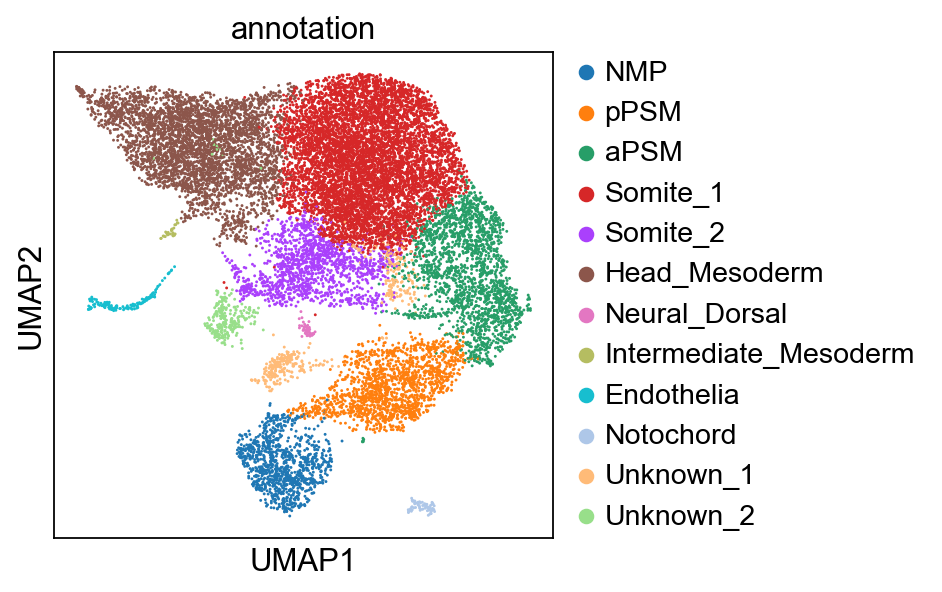

In [96]:
sc.pl.umap(adata_subset, color='annotation', save="20241113_HOXsamples_UMAP_Harmony_clustersall.pdf")

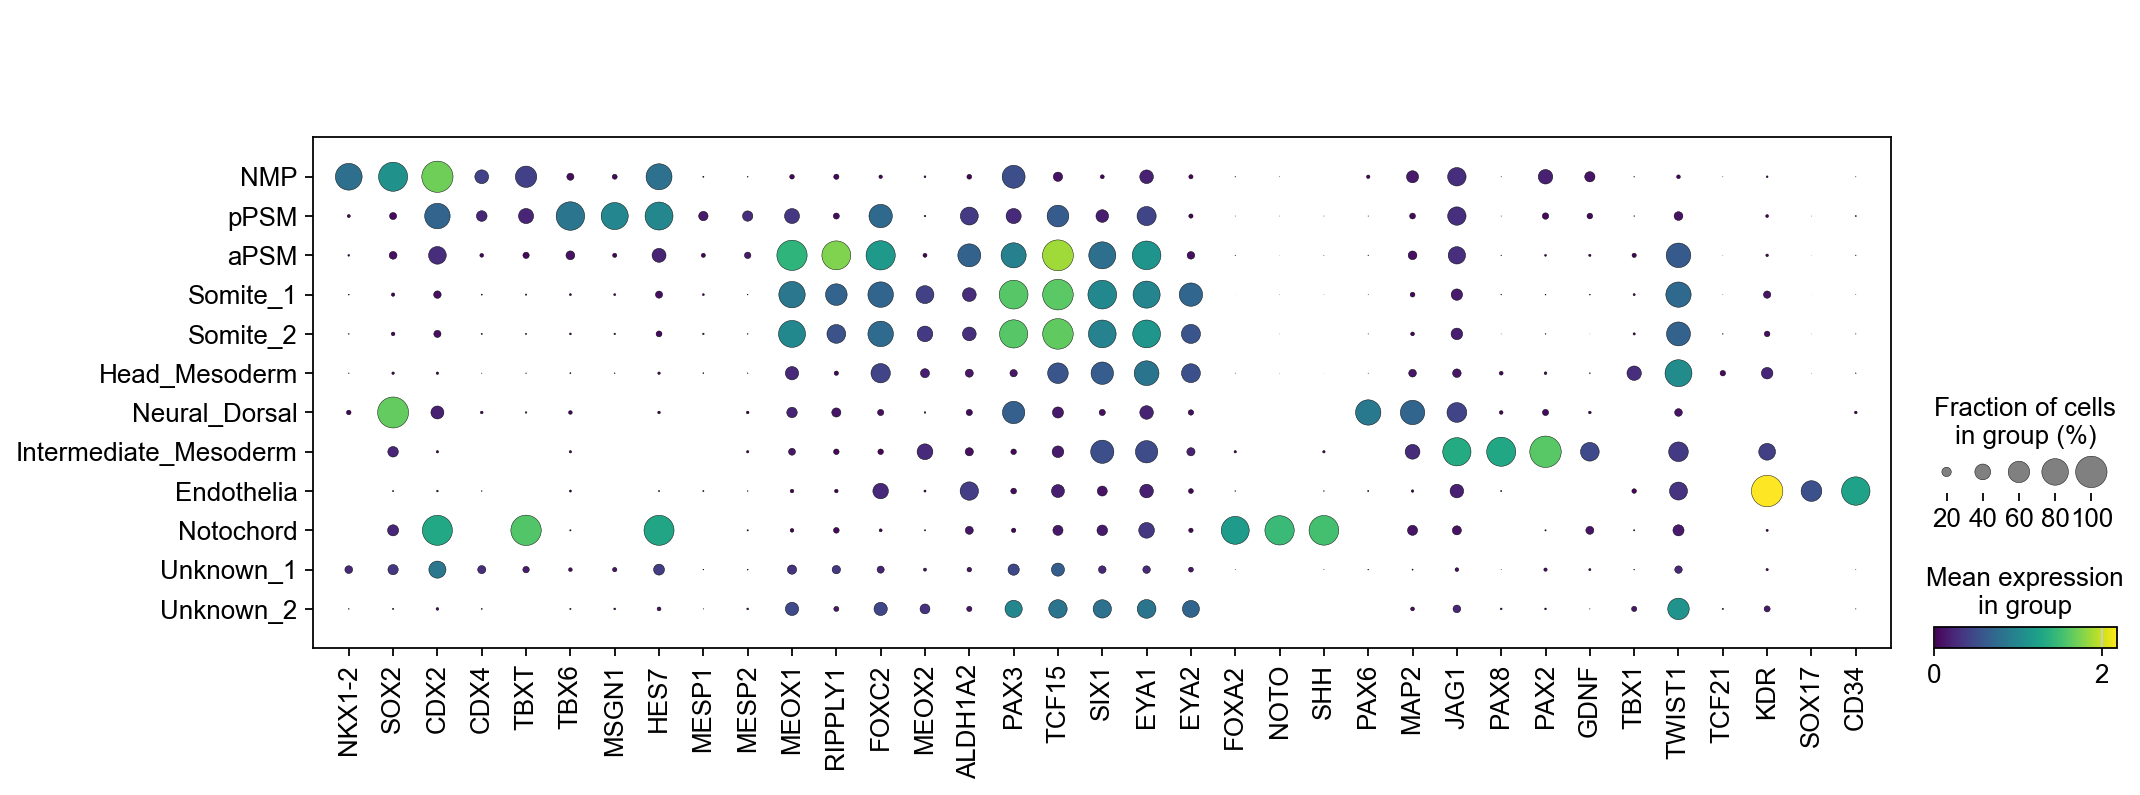

In [97]:
sc.pl.dotplot(adata_subset, genes, groupby='annotation',color_map="viridis", save= "20241113_HOXsamples_MARKERSdotplot_Harmony_clusters.pdf")

Scaled version of the plot:

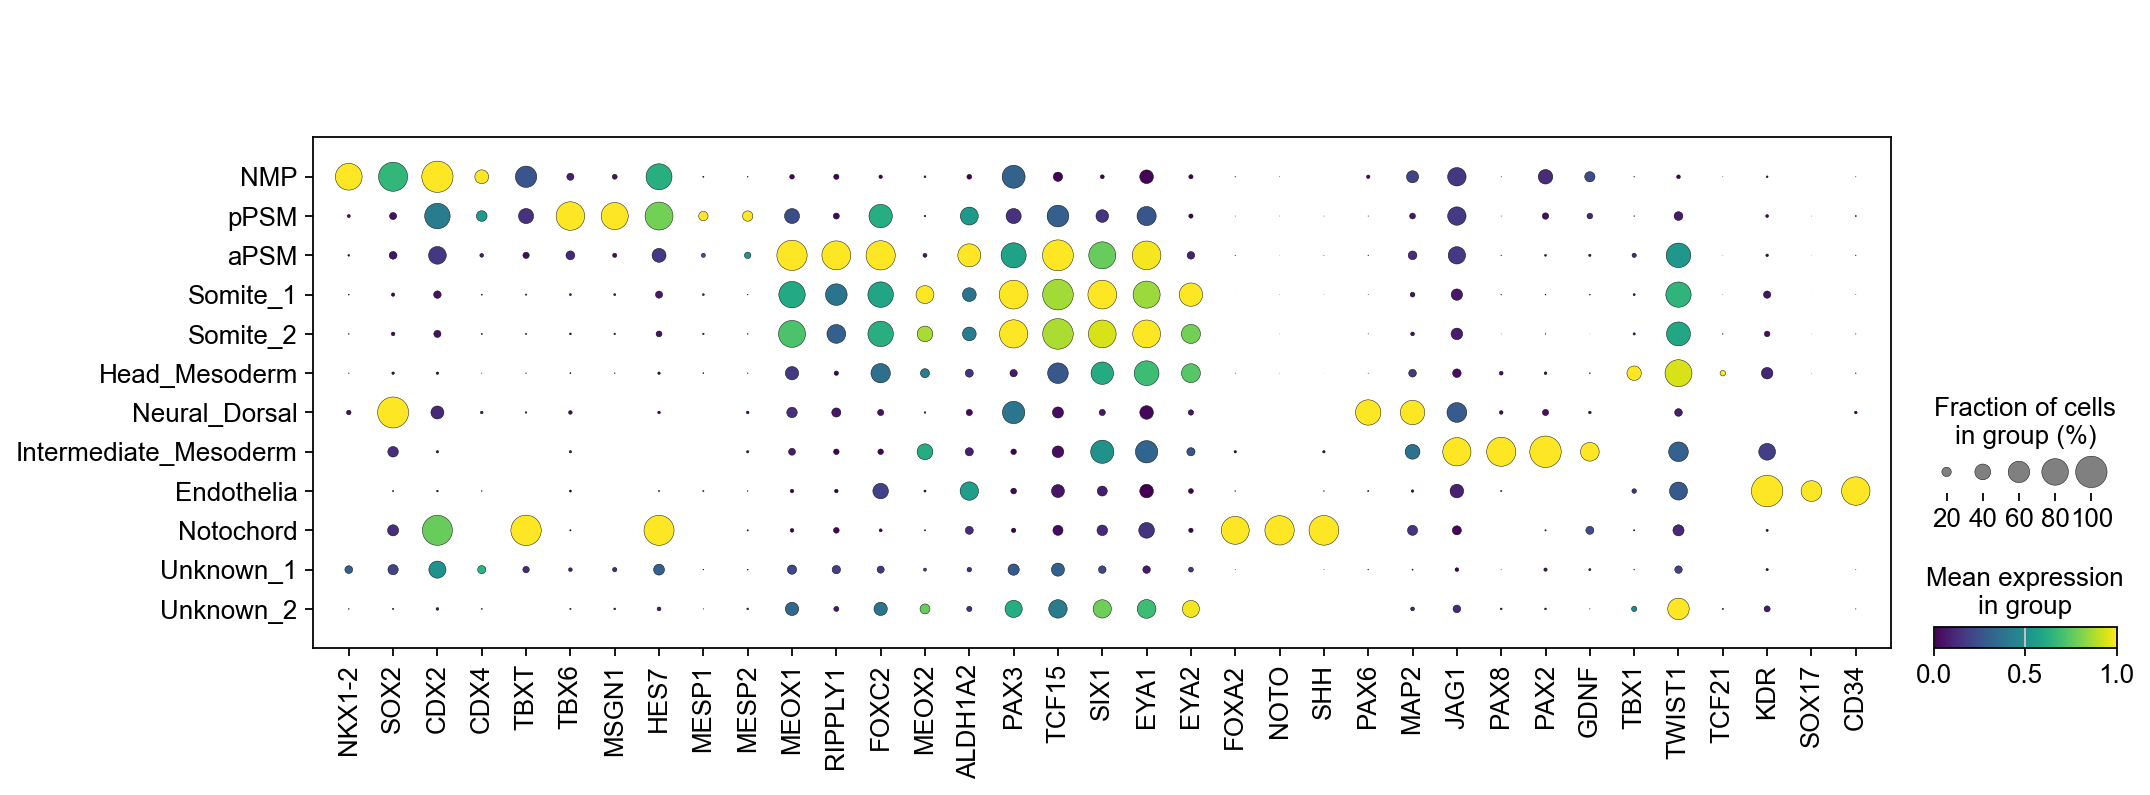

In [98]:
sc.pl.dotplot(adata_subset, genes, groupby='annotation',color_map="viridis", standard_scale="var",  save= "20241113_HOXsamples_MARKERSdotplot_Harmony_clusters_std.pdf")

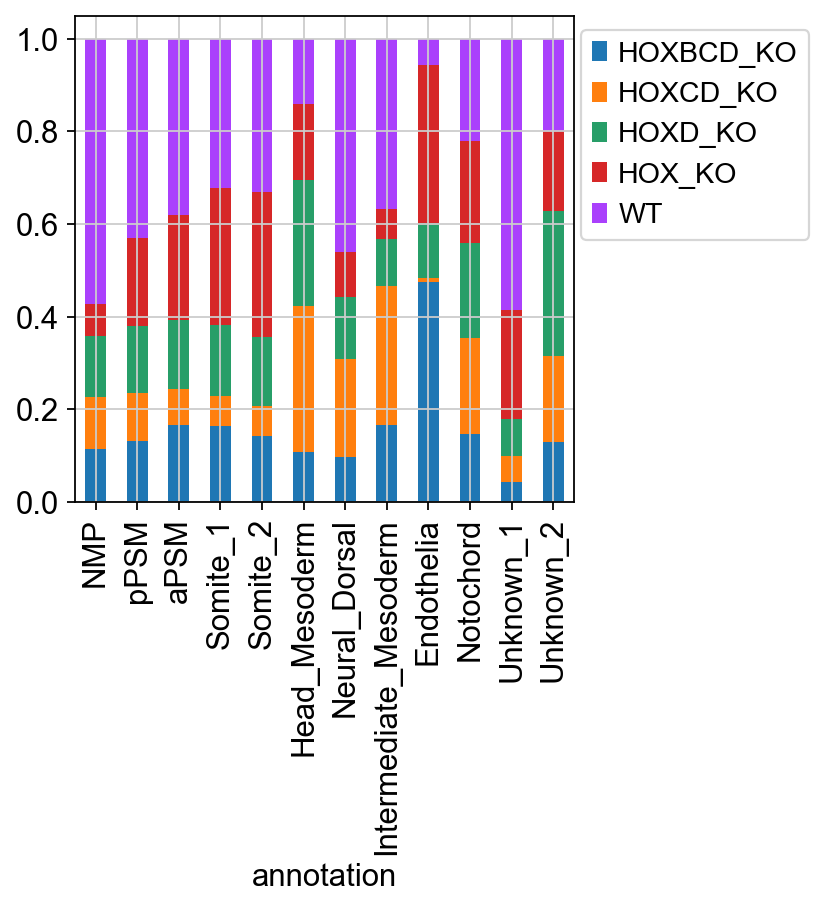

In [99]:
tmp = pd.crosstab(adata_subset.obs['annotation'],adata_subset.obs['sample'], normalize='index')
tmp.plot.bar(stacked=True).legend(loc='upper right',bbox_to_anchor=(1.5,1))
plt.savefig('figures/20241113_HOXsamples_proportion_allclusters.pdf', format='pdf', dpi=300, bbox_inches='tight')

In [100]:
# check that the matrix looks like normalized counts
print(adata.X[1:10,1:10])

  (0, 6)	0.547740638256073
  (3, 4)	0.33367305994033813
  (8, 4)	0.2874073386192322
  (8, 6)	0.510386049747467


In [101]:
print(adata.raw.X[1:10,1:10]) 

  (0, 6)	0.547740638256073
  (3, 4)	0.33367305994033813
  (8, 4)	0.2874073386192322
  (8, 6)	0.510386049747467


In [102]:
adata_subset.write_h5ad('H5AD/20241113_HOXsamples_all_qc_filtered_dr_Harmony_clustered_anno.h5ad')